# Báo cáo học thuật tổng hợp cuối

**Dự báo thời tiết Hà Nội lúc 12:00 bằng Machine Learning**

Notebook này được chuyển đổi từ `reports/final_synthesized_academic_report.md` để có thể mở bằng Google Colab/Jupyter. Nội dung là báo cáo học thuật tổng hợp từ các kết quả ngày kế tiếp, dự báo 7 ngày, hyperparameter tuning và phân tích mô hình.


# Tóm tắt

Báo cáo này tổng hợp và hệ thống hóa kết quả từ ba báo cáo đã xây dựng
trước đó: `hanoi_noon_weather_academic_report.md`,
`combined_weather_academic_report.md` và
`combined_weather_academic_report_enhanced.md`. Mục tiêu là tạo ra một
bản báo cáo học thuật thống nhất, trình bày đầy đủ từ bài toán dự báo
ngày kế tiếp đến bài toán dự báo 7 ngày, đồng thời bổ sung phân tích
hyperparameter tuning, threshold tuning và so sánh giữa hai mức tìm kiếm
cấu hình `n_iter=4` và `n_iter=20`.

Nghiên cứu sử dụng dữ liệu Open-Meteo cho khu vực Hà Nội trong giai đoạn
2020-2025. Tập dữ liệu ban đầu có 52.608 bản ghi theo giờ; sau tiền xử
lý chỉ giữ quan sát lúc 12:00, dữ liệu còn 2.192 bản ghi. Hệ thống giải
quyết hai nhiệm vụ học máy: dự báo nhiệt độ dưới dạng hồi quy và dự báo
mưa dưới dạng phân loại nhị phân. Với bài toán ngày kế tiếp, Linear
Regression đạt kết quả tốt nhất cho nhiệt độ với RMSE test 2,319°C và R2
0,808. Với bài toán mưa ngày kế tiếp, SVM được chọn theo F1 trên
validation set và đạt F1 test 0,673.

Đối với dự báo 7 ngày, pipeline được mở rộng theo hướng direct
multi-horizon: mỗi horizon từ 1 đến 7 có một mô hình nhiệt độ và một mô
hình mưa riêng. Phiên bản tuned tăng số cấu hình `RandomizedSearchCV` từ
4 lên 20, làm RMSE test trung bình của nhiệt độ giảm từ 3,290 xuống
3,159 và F1 test trung bình của mưa tăng từ 0,625 lên 0,632. Kết quả cho
thấy việc tuning sâu hơn có cải thiện, đặc biệt ở các horizon xa, nhưng
không giải quyết hoàn toàn khó khăn của bài toán mưa do mưa là hiện
tượng thưa, cục bộ và biến động mạnh.


# 1. Giới thiệu

Dự báo thời tiết là một bài toán có giá trị thực tiễn cao trong sinh
hoạt, giao thông, giáo dục, lao động ngoài trời và quản lý đô thị. Trong
nghiên cứu này, hệ thống tập trung vào thời điểm 12:00 trưa tại Hà Nội.
Việc cố định thời điểm dự báo làm cho bài toán có mục tiêu rõ ràng hơn,
tránh trộn lẫn biến động theo giờ và giúp các mô hình học máy tập trung
vào quan hệ giữa trạng thái khí tượng lịch sử và thời tiết tương lai tại
cùng một mốc thời gian trong ngày.

Hai bài toán học máy được đặt ra:

- Dự báo nhiệt độ lúc 12:00, là bài toán hồi quy.
- Dự báo có mưa hay không lúc 12:00, là bài toán phân loại nhị phân.

Bên cạnh hai đầu ra chính, hệ thống suy ra mức thời tiết từ nhiệt độ dự
báo:

``` text
temperature < 22        -> cool
22 <= temperature <= 30 -> normal
temperature > 30        -> hot
```

Mức thời tiết không được huấn luyện bằng mô hình riêng vì đây là biến
suy diễn trực tiếp từ nhiệt độ. Cách thiết kế này làm giảm độ phức tạp
không cần thiết và tránh tạo thêm một nguồn sai số độc lập.


# 2. Dữ liệu nghiên cứu

## 2.1. Nguồn dữ liệu

Dữ liệu được thu thập từ Open-Meteo cho khu vực Hà Nội, gồm các biến khí
tượng như nhiệt độ, độ ẩm tương đối, lượng mưa, mây che phủ, áp suất mực
nước biển, tốc độ gió ở độ cao 10m và bức xạ sóng ngắn. Khoảng thời gian
dữ liệu là từ ngày 2020-01-01 đến ngày 2025-12-31.

| Thuộc tính                                  |                   Giá trị |
|---------------------------------------------|--------------------------:|
| Số bản ghi theo giờ ban đầu                 |                    52.608 |
| Số bản ghi lúc 12:00 sau tiền xử lý         |                     2.192 |
| Số mẫu supervised cho bài toán ngày kế tiếp |                     2.191 |
| Khoảng thời gian dữ liệu                    | 2020-01-01 đến 2025-12-31 |
| Tỷ lệ mưa ngày kế tiếp                      |                     0,390 |
| Bản ghi mới nhất dùng cho suy luận 7 ngày   |       2025-12-30 12:00:00 |

## 2.2. Thống kê mô tả

| Biến                |     Mean |     Std |     Min |   Median |      Max |
|---------------------|---------:|--------:|--------:|---------:|---------:|
| temperature         |   26,906 |   5,497 |   8,900 |   27,800 |   38,000 |
| humidity            |   67,167 |  12,306 |  22,000 |   68,000 |   96,000 |
| precipitation       |    0,255 |   0,957 |   0,000 |    0,000 |   13,800 |
| cloud_cover         |   77,693 |  33,656 |   0,000 |   99,000 |  100,000 |
| pressure_msl        | 1011,833 |   7,343 | 990,500 | 1011,300 | 1032,300 |
| wind_speed_10m      |    9,766 |   5,027 |   0,000 |    9,300 |   38,000 |
| shortwave_radiation |  547,390 | 235,568 |  59,000 |  568,500 |  949,000 |

Nhiệt độ trung bình lúc 12:00 là 26,906°C với độ lệch chuẩn 5,497°C.
Điều này cho thấy biến thiên mùa vụ rõ rệt: các giai đoạn lạnh có thể
xuống dưới 10°C, trong khi mùa nóng có thể đạt 38°C vào buổi trưa. Lượng
mưa có median bằng 0 mm, nghĩa là ít nhất một nửa số ngày không có mưa
tại thời điểm 12:00. Độ lệch chuẩn lượng mưa lớn hơn mean, phản ánh phân
phối lệch phải: phần lớn quan sát có mưa bằng 0 hoặc rất nhỏ, trong khi
một số ngày có mưa lớn. Đặc điểm này làm cho bài toán phân loại mưa khó
hơn bài toán hồi quy nhiệt độ.

Cloud cover có median 99%, cho thấy nhiều quan sát buổi trưa có mây che
phủ cao. Shortwave radiation dao động từ 59 đến 949, do đó biến này được
đưa vào thí nghiệm A/B ở pipeline ngày kế tiếp để kiểm tra tác động đến
hiệu quả dự báo.


# 3. Tiền xử lý và tạo đặc trưng

Quy trình tiền xử lý gồm các bước:

1.  Phát hiện và loại bỏ các dòng metadata của Open-Meteo.
2.  Chuẩn hóa tên cột.
3.  Chuyển cột thời gian sang kiểu datetime.
4.  Sắp xếp dữ liệu theo thời gian.
5.  Loại bỏ timestamp trùng lặp.
6.  Chỉ giữ các quan sát lúc 12:00.
7.  Loại bỏ các cột không dùng hoặc có nguy cơ trùng thông tin, gồm
    `surface_pressure`, `wind_direction_10m` và `rain`.
8.  Điền missing numeric bằng median nếu có.
9.  Loại bỏ các dòng không có target sau khi tạo nhãn tương lai.

Cột `rain` bị loại bỏ vì có thể trùng lặp thông tin với `precipitation`;
trong khi đó, nhãn mưa được định nghĩa lại từ lượng mưa tương lai theo
điều kiện `precipitation > 0`. Quyết định này giúp giảm rủi ro rò rỉ dữ
liệu và làm cho nhãn phân loại nhất quán.

Các nhóm đặc trưng chính gồm:

- Đặc trưng thời gian: `month`, `day_of_year`, `season`.
- Đặc trưng trễ: lag 1, 3 và 7 ngày cho nhiệt độ, độ ẩm và lượng mưa.
- Đặc trưng rolling: trung bình trượt nhiệt độ, trung bình trượt độ ẩm
  và tổng lượng mưa trên cửa sổ 3 và 7 ngày.

Các đặc trưng rolling được tính bằng `shift(1)` trước khi áp dụng
`rolling()`. Đây là điểm quan trọng về phương pháp luận vì nó bảo đảm mô
hình chỉ sử dụng thông tin quá khứ, không dùng dữ liệu của chính ngày
cần dự báo.


# 4. Trực quan hóa dữ liệu

## 4.1. Xu hướng và phân phối nhiệt độ

<figure>
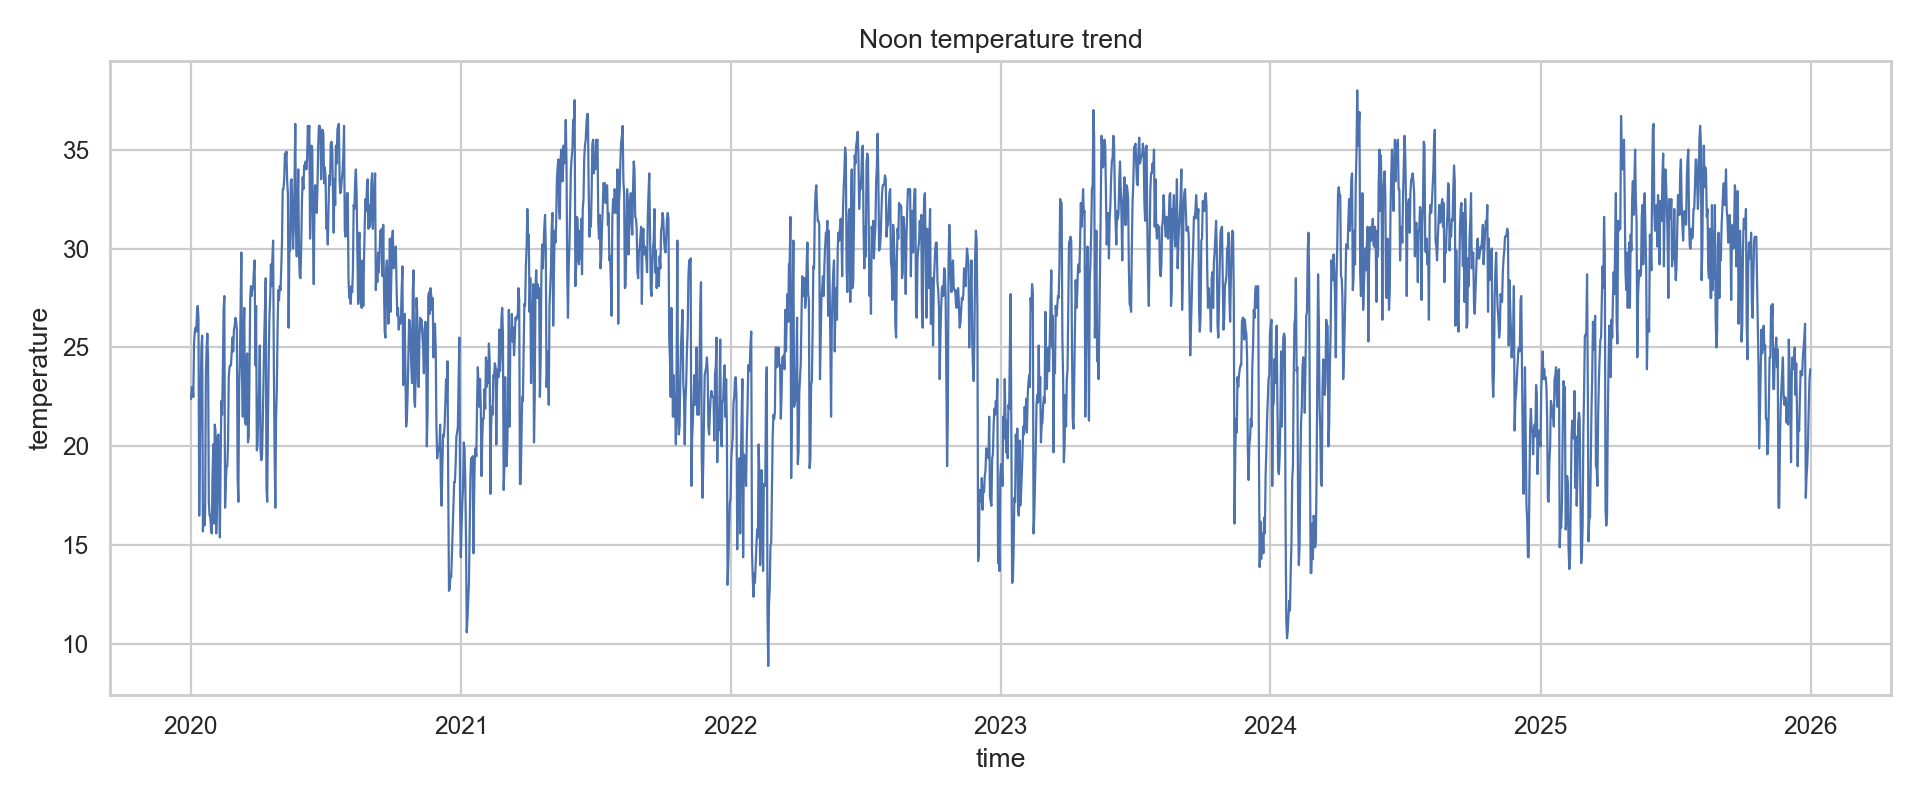
<figcaption aria-hidden="true">Xu hướng nhiệt độ lúc 12:00</figcaption>
</figure>

Biểu đồ xu hướng nhiệt độ cho thấy chu kỳ mùa vụ rõ rệt qua các năm.
Nhiệt độ tăng trong các tháng nóng và giảm trong các giai đoạn lạnh. Đây
là cơ sở để đưa các đặc trưng thời gian như `month`, `season` và
`day_of_year` vào mô hình.

<figure>
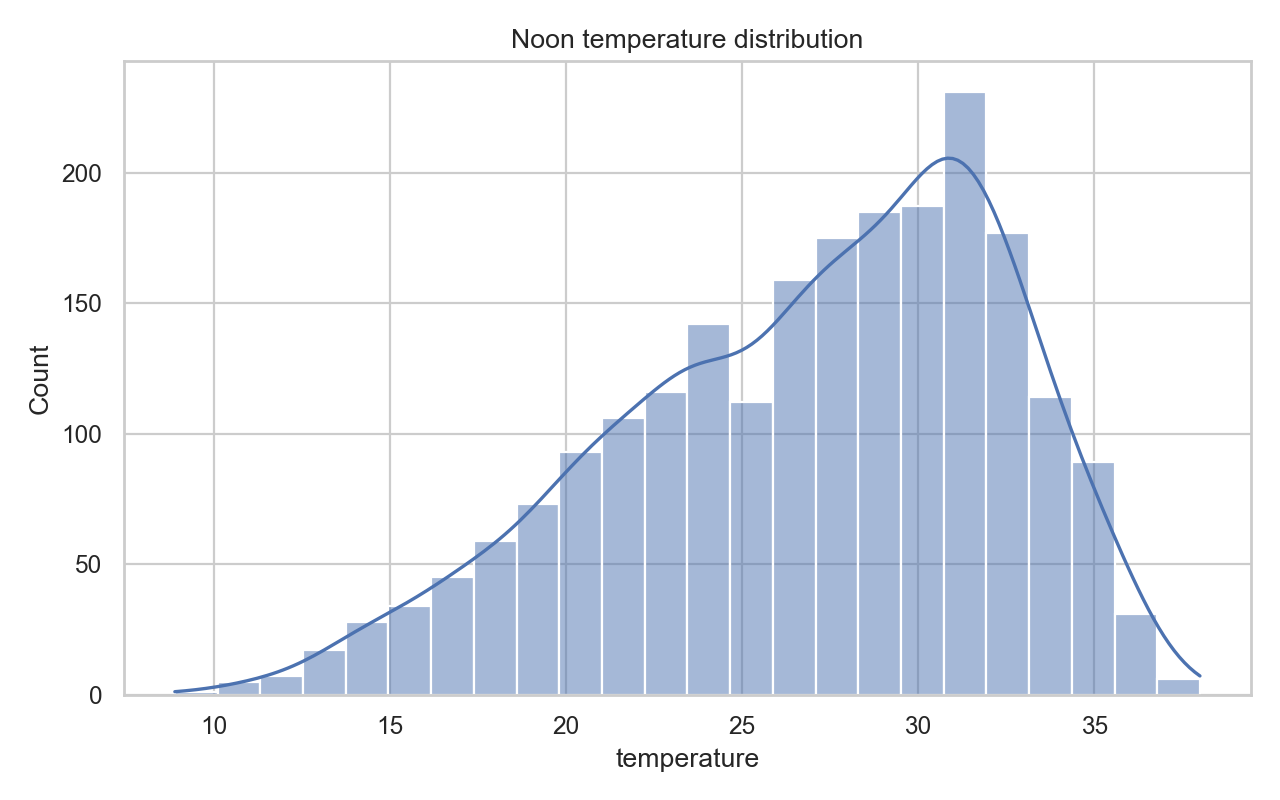
<figcaption aria-hidden="true">Phân phối nhiệt độ</figcaption>
</figure>

Phân phối nhiệt độ cho thấy phần lớn quan sát tập trung quanh vùng nhiệt
độ trung bình đến nóng, phù hợp với đặc điểm khí hậu Hà Nội.

## 4.2. Correlation heatmap

<figure>
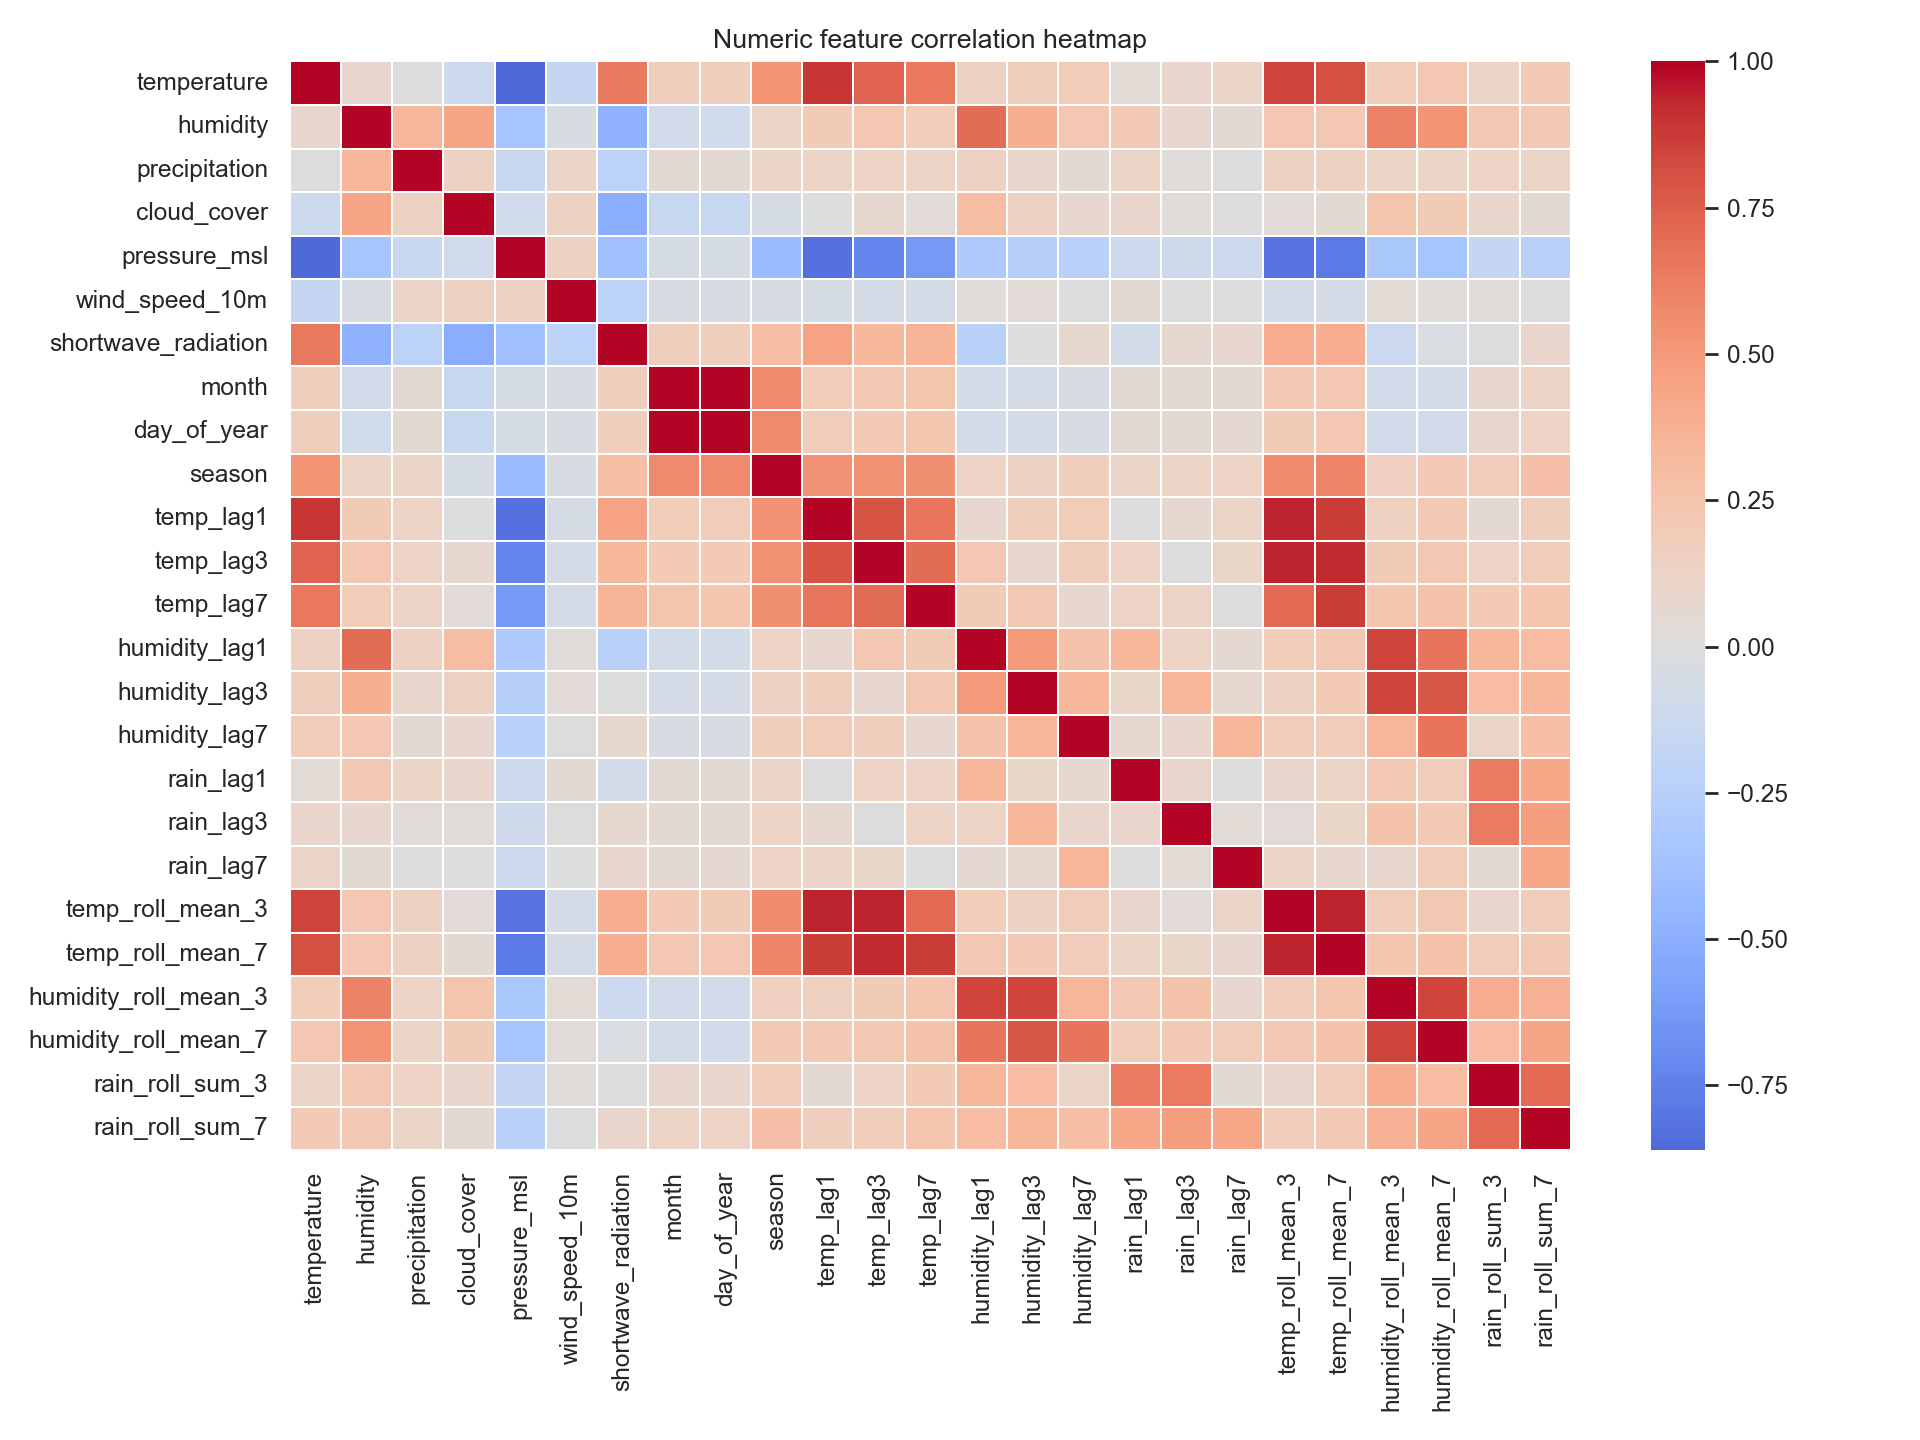
<figcaption aria-hidden="true">Correlation heatmap</figcaption>
</figure>

Correlation heatmap mô tả quan hệ tuyến tính giữa các biến. Các đặc
trưng nhiệt độ hiện tại, nhiệt độ lag và rolling temperature có tương
quan cao. Điều này phù hợp với bản chất vật lý của nhiệt độ: trạng thái
nhiệt hôm nay thường chịu ảnh hưởng mạnh từ những ngày gần trước đó. Tuy
nhiên, tương quan cao cũng đặt ra vấn đề đa cộng tuyến khi diễn giải hệ
số Linear Regression. Do đó, hệ số tuyến tính và feature importance cần
được hiểu như tín hiệu mô hình, không nên diễn giải trực tiếp như quan
hệ nhân quả.

## 4.3. PCA

<figure>
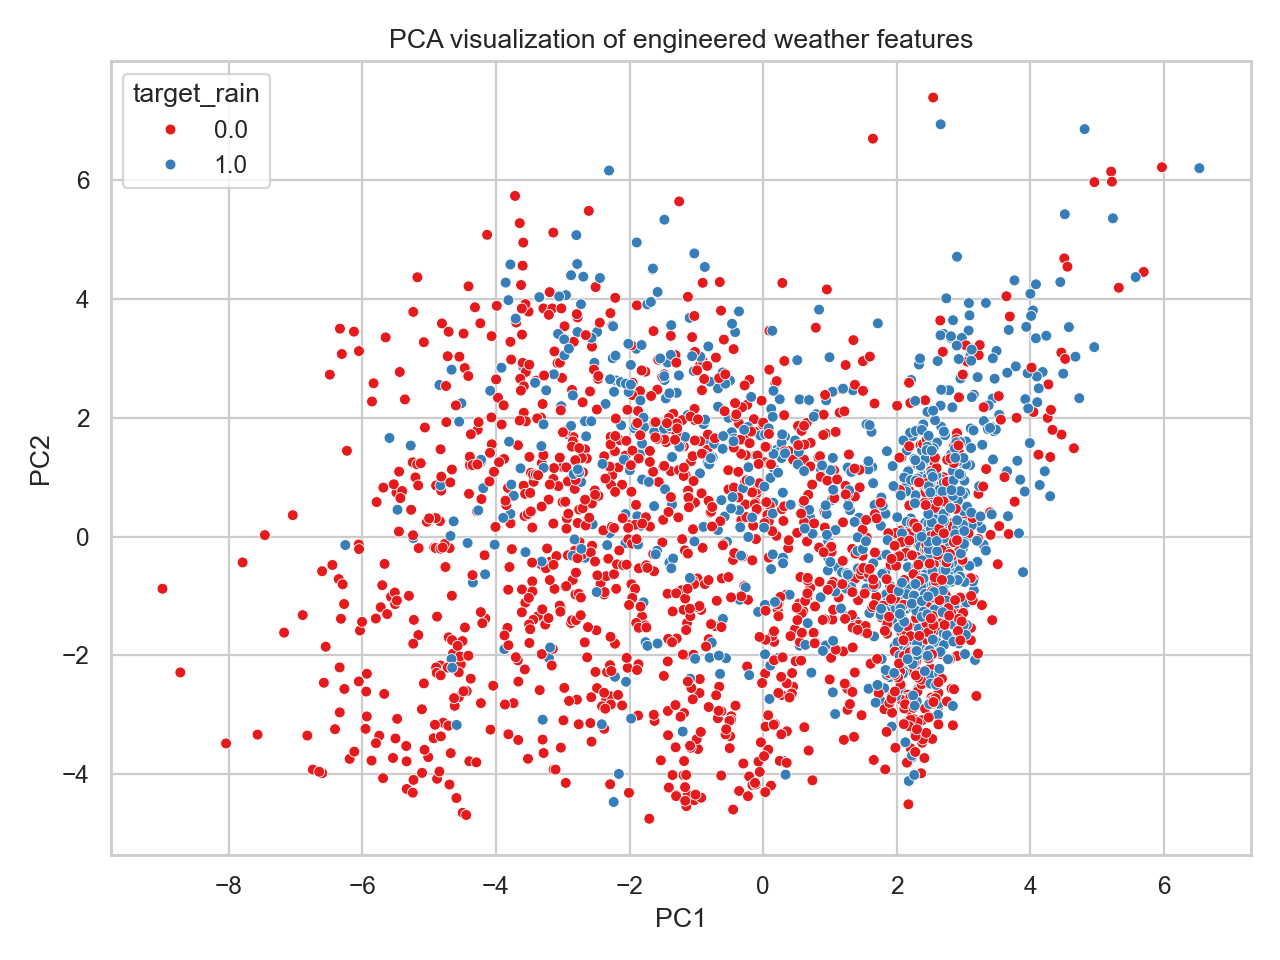
<figcaption aria-hidden="true">PCA visualization</figcaption>
</figure>

PCA giảm không gian đặc trưng nhiều chiều xuống hai thành phần chính PC1
và PC2. Các giá trị trên trục PCA như -4, -2, 0, 2, 4 là tọa độ trong
không gian mới sau phép biến đổi tuyến tính, không còn mang đơn vị khí
tượng gốc như °C, mm hay hPa. Nếu các điểm mưa và không mưa chồng lấn
nhiều trong không gian PCA, điều đó cho thấy bài toán phân loại mưa khó
tách bằng một ranh giới đơn giản trong hai chiều biểu diễn chính.


# 5. Thiết kế thực nghiệm

## 5.1. Chia train, validation và test

Dữ liệu được chia theo thứ tự thời gian thay vì chia ngẫu nhiên:

| Tập dữ liệu | Giai đoạn | Vai trò |
|------------------------|------------------------|------------------------|
| Training | 2020-2023 | Huấn luyện trọng số và tuning tham số bằng TimeSeriesSplit |
| Validation | 2024 | Chọn model cuối và chọn threshold mưa |
| Test | 2025 | Đánh giá cuối cùng trên dữ liệu chưa dùng để chọn |

Chia theo thời gian là bắt buộc trong bài toán dự báo vì mô hình chỉ
được học từ quá khứ để dự đoán tương lai. Nếu chia ngẫu nhiên, dữ liệu
tương lai có thể xuất hiện trong training set, làm kết quả đánh giá bị
lạc quan giả tạo.

## 5.2. Baseline

Hai baseline được sử dụng làm mốc so sánh:

- Temperature baseline: dự báo nhiệt độ ngày mai bằng nhiệt độ hôm nay.
  Đây là persistence baseline, phù hợp với tính liên tục của nhiệt độ.
- Rain baseline: luôn dự báo lớp phổ biến nhất trong training set, tương
  đương `DummyClassifier(strategy="most_frequent")`.

Baseline không phải là mô hình học máy phức tạp. Vai trò của baseline là
kiểm tra xem các mô hình học máy có thực sự tạo thêm giá trị so với
chiến lược dự báo đơn giản hay không.

## 5.3. Mô hình

Nhóm hồi quy nhiệt độ gồm:

- Linear Regression.
- KNN Regressor.
- XGBoost Regressor.

Nhóm phân loại mưa gồm:

- Logistic Regression với `class_weight='balanced'`.
- SVM với `class_weight='balanced'`.
- XGBoost Classifier với `scale_pos_weight` tự động theo tỷ lệ lớp.

Các mô hình nhạy với thang đo như Linear Regression, Logistic
Regression, SVM và KNN được kết hợp với `StandardScaler`. XGBoost là mô
hình cây nên không yêu cầu chuẩn hóa đặc trưng.


# 6. Hyperparameter tuning và threshold tuning

Hyperparameter tuning được thực hiện bằng `RandomizedSearchCV` kết hợp
`TimeSeriesSplit(n_splits=5)` trên training set. `TimeSeriesSplit` giữ
đúng thứ tự thời gian: mỗi fold huấn luyện trên một đoạn quá khứ và kiểm
tra trên đoạn tương lai ngay sau đó. Điều này phù hợp với bản chất chuỗi
thời gian hơn KFold ngẫu nhiên.

Ở bài toán hồi quy, cấu hình tốt nhất được chọn theo negative RMSE trong
cross-validation. Khi báo cáo, giá trị này được đổi dấu thành mean CV
RMSE, trong đó thấp hơn là tốt hơn. Ở bài toán phân loại, cấu hình tốt
nhất được chọn theo F1 trong cross-validation, trong đó cao hơn là tốt
hơn.

Linear Regression không có hyperparameter tuning trong pipeline hiện tại
vì mô hình được fit bằng ordinary least squares sau chuẩn hóa. KNN tune
`n_neighbors` và `weights`. XGBoost tune `n_estimators`, `max_depth` và
`learning_rate`. Logistic Regression tune `C`. SVM tune `C` và `kernel`.

Sau khi mô hình phân loại sinh xác suất mưa, pipeline không sử dụng cố
định threshold 0,5. Threshold được thử từ 0,10 đến 0,90 với bước 0,05
trên validation set; threshold tốt nhất là threshold tối đa hóa F1
validation. Như vậy, nhóm classification có hai lớp tuning: tuning tham
số mô hình trên training cross-validation và tuning ngưỡng quyết định
trên validation set.


# 7. Kết quả dự báo ngày kế tiếp

## 7.1. Hồi quy nhiệt độ

Kết quả validation:

| Mô hình           |   MAE |  RMSE |    R2 |
|-------------------|------:|------:|------:|
| Linear Regression | 1,811 | 2,375 | 0,814 |
| KNN Regressor     | 2,214 | 2,761 | 0,749 |
| XGBoost Regressor | 1,893 | 2,439 | 0,804 |

Kết quả test:

| Mô hình           |   MAE |  RMSE |    R2 |
|-------------------|------:|------:|------:|
| Linear Regression | 1,674 | 2,319 | 0,808 |
| KNN Regressor     | 2,148 | 2,821 | 0,716 |
| XGBoost Regressor | 1,830 | 2,432 | 0,789 |

Linear Regression được chọn vì có RMSE thấp nhất trên validation set.
Trên test set, mô hình này tiếp tục đạt RMSE thấp nhất và R2 cao nhất.
Kết quả này cho thấy dự báo nhiệt độ ngày kế tiếp lúc 12:00 có cấu trúc
tương đối tuyến tính, trong đó nhiệt độ hiện tại, đặc trưng mùa vụ, lag
và rolling đã chứa phần lớn tín hiệu dự báo.

<figure>
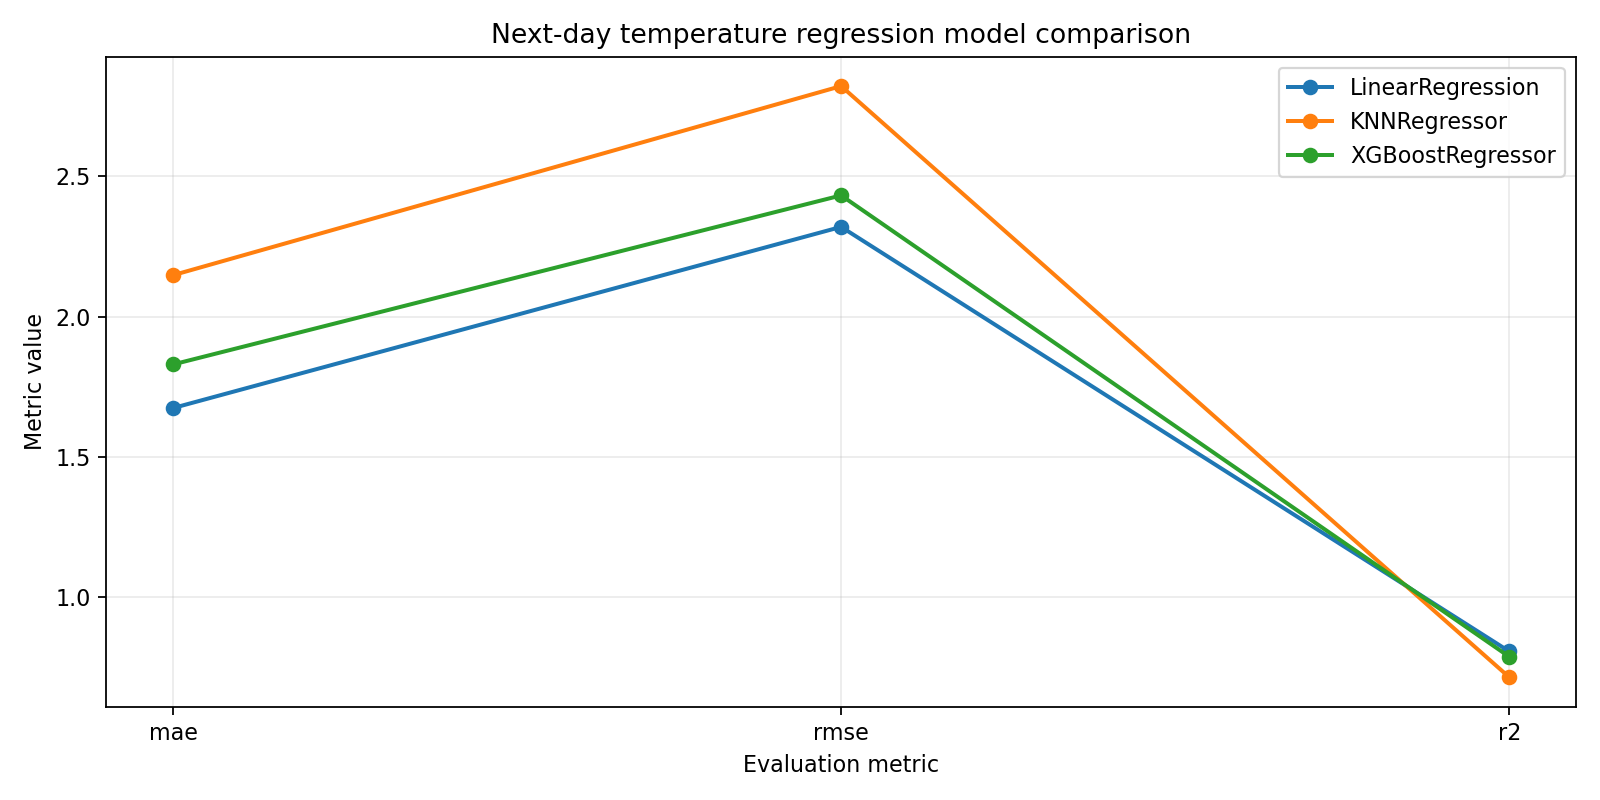
<figcaption aria-hidden="true">So sánh mô hình hồi quy ngày kế tiếp dạng
line</figcaption>
</figure>

<figure>
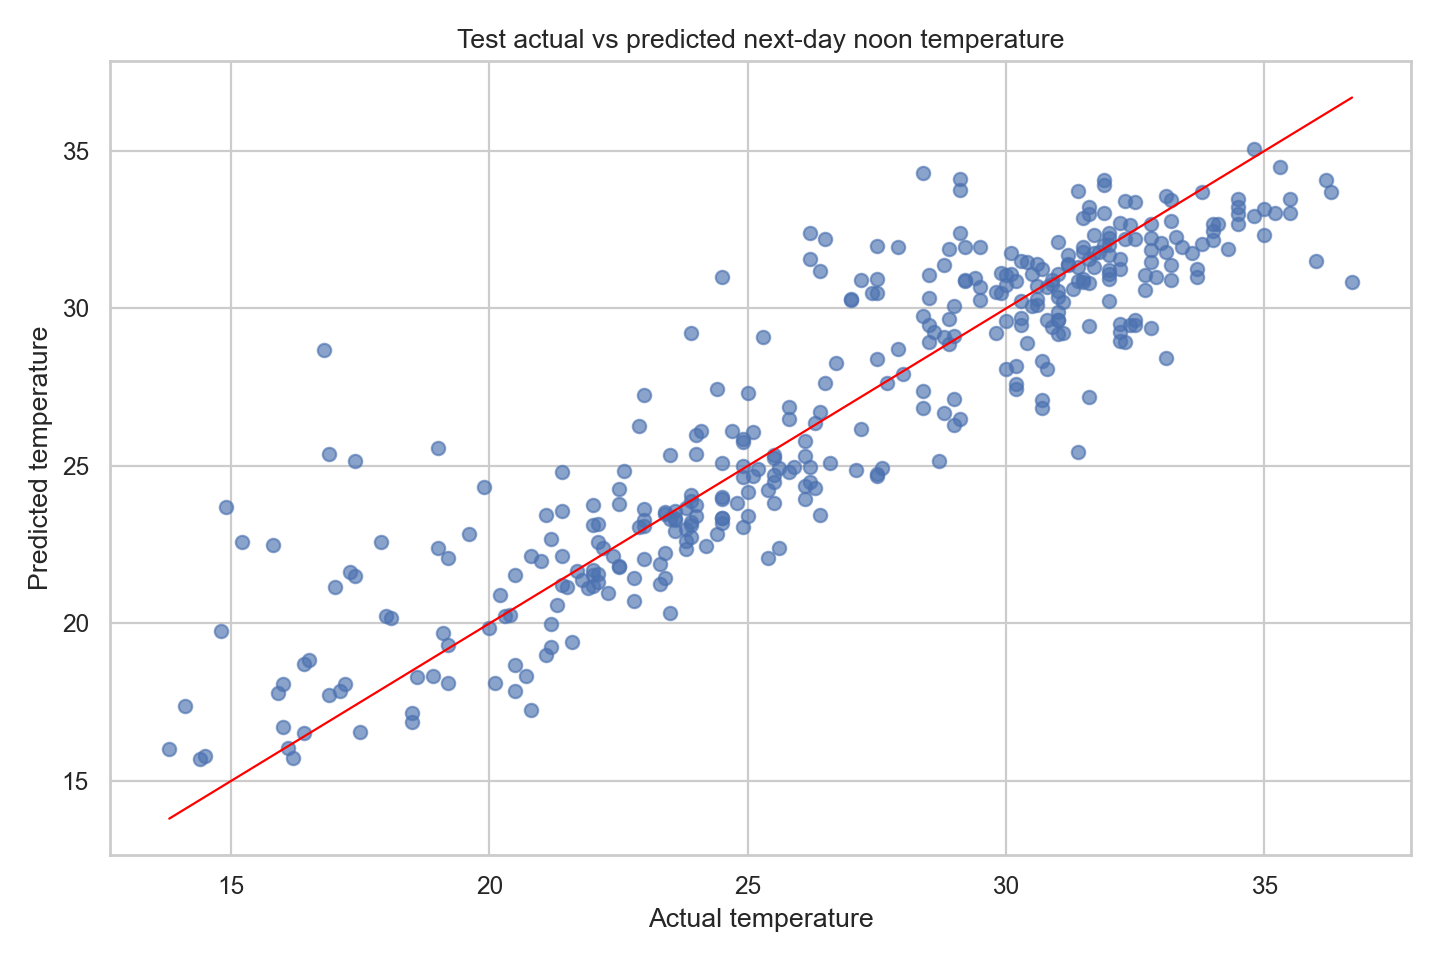
<figcaption aria-hidden="true">Actual vs predicted temperature trên test
set</figcaption>
</figure>

<figure>
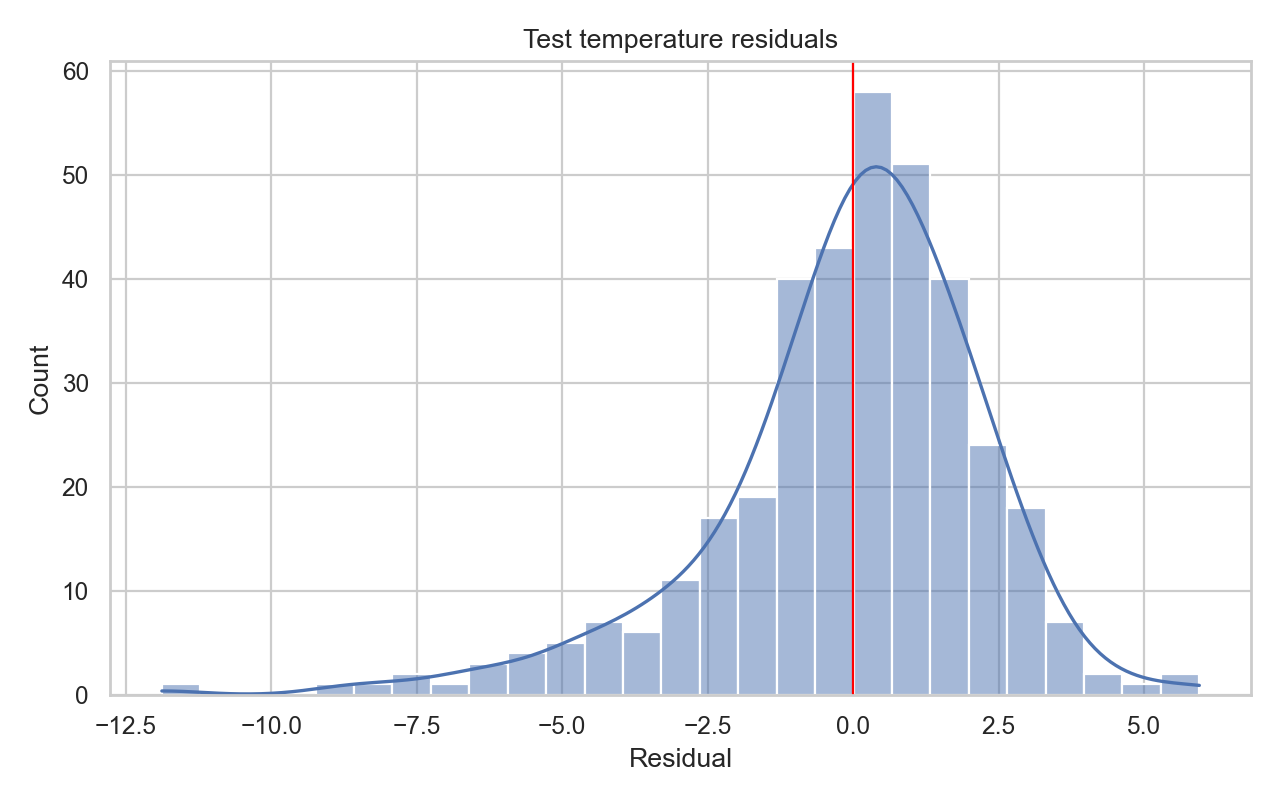
<figcaption aria-hidden="true">Temperature residuals trên test
set</figcaption>
</figure>

Đối với hồi quy, không nên đánh giá đúng/sai tuyệt đối như phân loại. Vì
vậy, báo cáo dùng thêm các ngưỡng sai số:

| Tập dữ liệu |   MAE |  RMSE | Trong ±1°C | Trong ±2°C | Trong ±3°C |
|-------------|------:|------:|-----------:|-----------:|-----------:|
| Validation  | 1,811 | 2,375 |      0,388 |      0,653 |      0,806 |
| Test        | 1,674 | 2,319 |      0,420 |      0,692 |      0,849 |

Trên test set, khoảng 69,2% dự báo nằm trong sai số ±2°C và 84,9% nằm
trong ±3°C. Đây là kết quả hợp lý với một hệ thống sử dụng dữ liệu lịch
sử tại một điểm không gian.

## 7.2. Trọng số w và hệ số chặn b của Linear Regression

Đối với Linear Regression, quá trình huấn luyện không tìm kiếm
hyperparameter như `n_neighbors`, `max_depth` hay `learning_rate`. Thay
vào đó, mô hình ước lượng trực tiếp bộ trọng số `w` và hệ số chặn `b`
bằng cách cực tiểu hóa hàm mất mát bình phương sai số trên training set.
Công thức dự báo có dạng:

``` text
y_hat = w1*x1 + w2*x2 + ... + wn*xn + b
```

Trong đó `x1 ... xn` là các đặc trưng đầu vào sau chuẩn hóa, `w1 ... wn`
là các hệ số tuyến tính học được, và `b` là hệ số chặn của mô hình. Vì
pipeline sử dụng `StandardScaler` trước Linear Regression, các hệ số `w`
được diễn giải trong không gian đặc trưng đã chuẩn hóa. Do đó, độ lớn
của hệ số cho biết mức đóng góp tương đối của đặc trưng sau chuẩn hóa,
không phải mức thay đổi trực tiếp theo đơn vị gốc như °C, mm hay hPa.

Các hệ số có độ lớn cao nhất trong mô hình nhiệt độ ngày kế tiếp gồm:

| Đặc trưng        | Hệ số w | Hướng tác động |
|------------------|--------:|----------------|
| temperature      |   4,485 | positive       |
| day_of_year      |  -1,007 | negative       |
| temp_lag1        |  -0,881 | negative       |
| month            |   0,851 | positive       |
| temp_lag7        |   0,540 | positive       |
| humidity         |   0,391 | positive       |
| temp_roll_mean_3 |   0,285 | positive       |
| pressure_msl     |  -0,267 | negative       |
| temp_lag3        |   0,214 | positive       |
| season           |   0,208 | positive       |

Hệ số dương nghĩa là khi đặc trưng đó tăng trong không gian đã chuẩn
hóa, dự báo nhiệt độ có xu hướng tăng nếu các đặc trưng khác giữ nguyên.
Hệ số âm nghĩa là đặc trưng đó có quan hệ ngược chiều với nhiệt độ dự
báo trong mô hình tuyến tính. Ví dụ, hệ số của `temperature` lớn và
dương cho thấy nhiệt độ hiện tại là tín hiệu mạnh nhất cho nhiệt độ ngày
kế tiếp. Các đặc trưng mùa vụ như `day_of_year`, `month` và `season`
cũng có hệ số đáng kể, phản ánh chu kỳ khí hậu theo năm.

Điểm cần nhấn mạnh là `w` và `b` không phải là “tham số tuned tốt nhất”
theo nghĩa hyperparameter tuning. Chúng là tham số mô hình được học trực
tiếp từ dữ liệu training. Bảng đầy đủ các hệ số được lưu trong
`reports/tables/linear_regression_coefficients.csv`, còn biểu đồ hệ số
được trình bày ở phần diễn giải mô hình.

## 7.3. Phân loại mưa

Kết quả validation:

| Mô hình             | Accuracy | Precision | Recall |    F1 | ROC AUC |
|---------------------|---------:|----------:|-------:|------:|--------:|
| Logistic Regression |    0,653 |     0,532 |  0,712 | 0,609 |   0,742 |
| SVM                 |    0,680 |     0,560 |  0,741 | 0,638 |   0,758 |
| XGBoost Classifier  |    0,686 |     0,574 |  0,669 | 0,618 |   0,751 |

Kết quả test:

| Mô hình             | Accuracy | Precision | Recall |    F1 | ROC AUC |
|---------------------|---------:|----------:|-------:|------:|--------:|
| Logistic Regression |    0,720 |     0,612 |  0,783 | 0,687 |   0,785 |
| SVM                 |    0,717 |     0,616 |  0,741 | 0,673 |   0,774 |
| XGBoost Classifier  |    0,698 |     0,611 |  0,636 | 0,623 |   0,767 |

SVM được chọn vì có F1 cao nhất trên validation set. Trên test set,
Logistic Regression có F1 cao hơn SVM, nhưng lựa chọn mô hình sau khi
nhìn test set sẽ vi phạm quy trình đánh giá. Do đó, SVM vẫn là mô hình
được chọn hợp lệ theo nguyên tắc validation-first.

<figure>
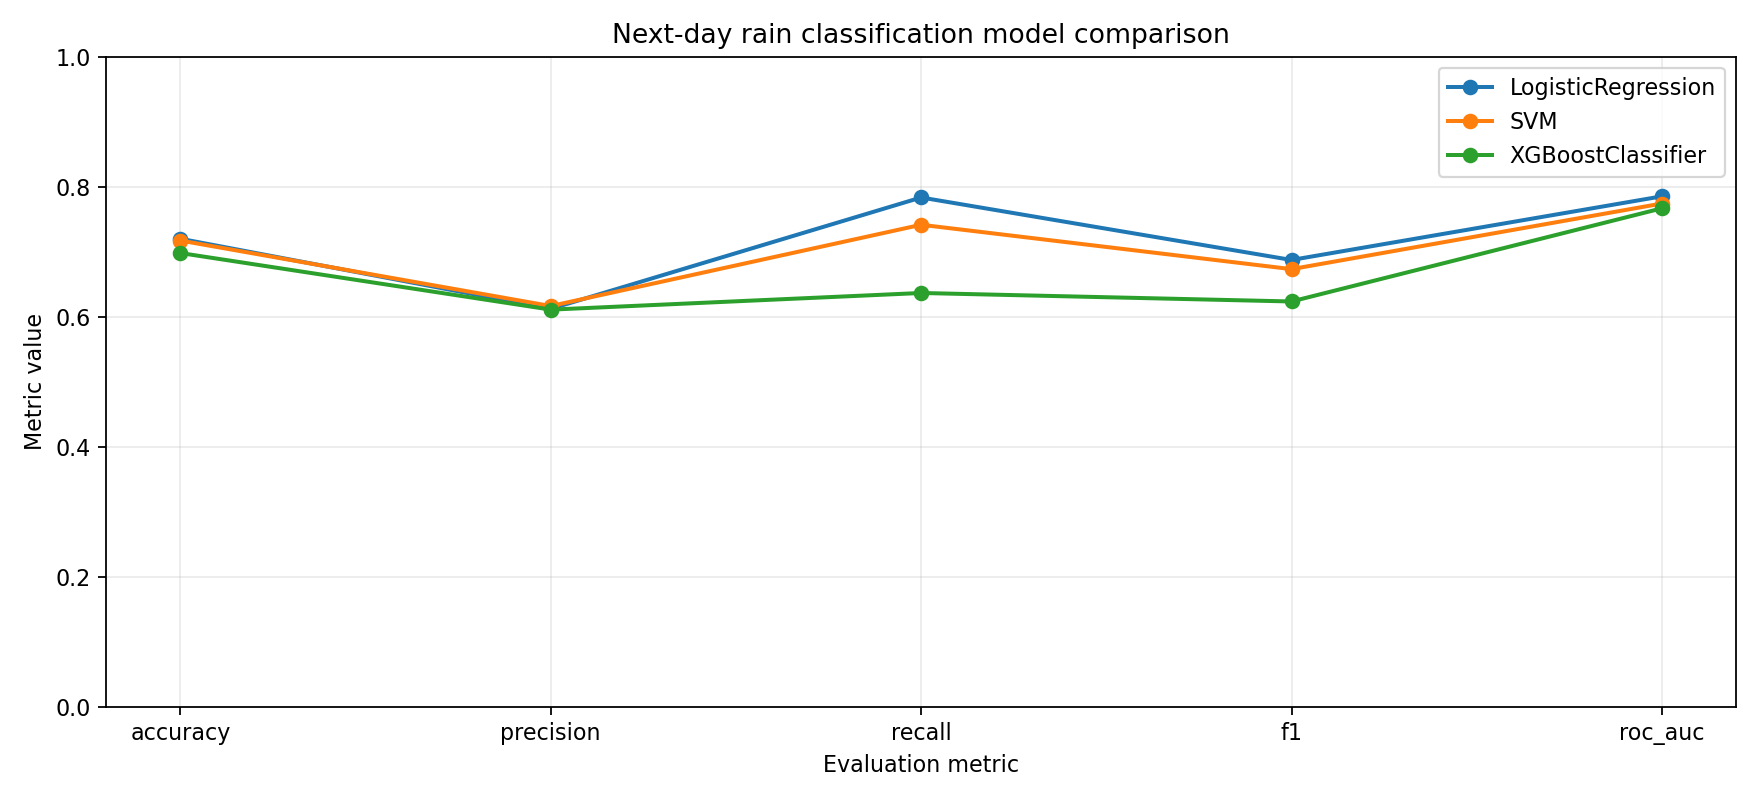
<figcaption aria-hidden="true">So sánh mô hình phân loại ngày kế tiếp
dạng line</figcaption>
</figure>

<figure>
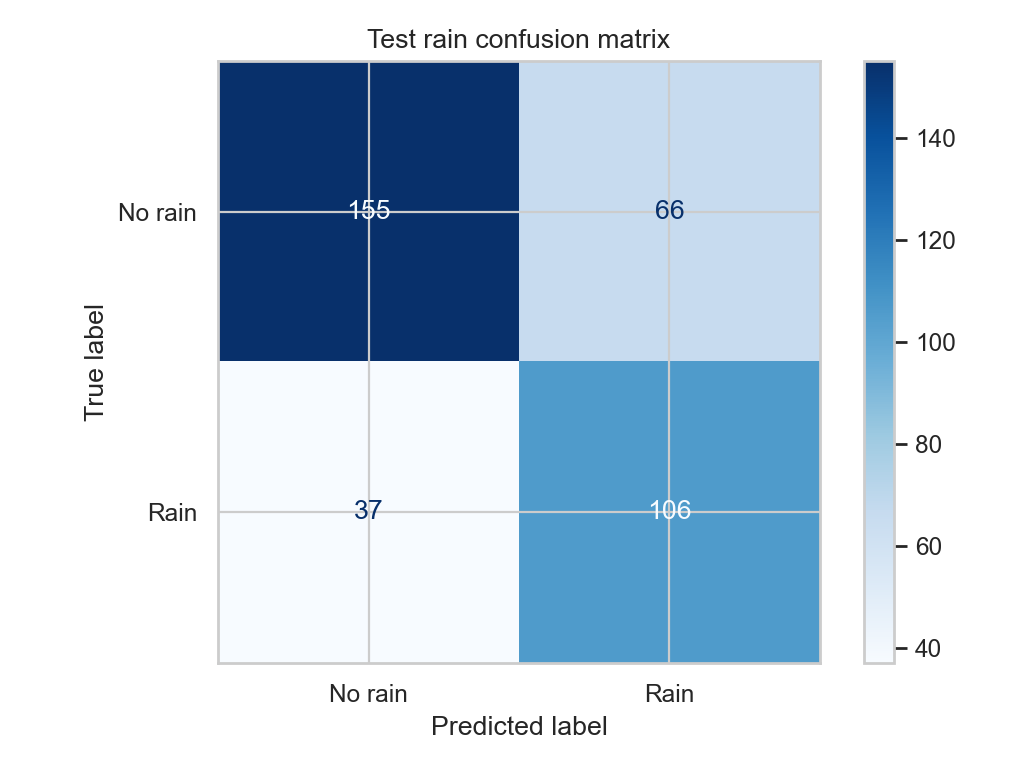
<figcaption aria-hidden="true">Confusion matrix trên test
set</figcaption>
</figure>

Confusion matrix cho biết mô hình dự báo đúng/sai ở từng lớp. False
negative nghĩa là thực tế có mưa nhưng mô hình dự báo không mưa; false
positive nghĩa là thực tế không mưa nhưng mô hình dự báo có mưa. Tùy ứng
dụng, false negative có thể nghiêm trọng hơn vì người dùng không chuẩn
bị cho mưa.

## 7.4. Thí nghiệm A/B với shortwave radiation

| Thí nghiệm | Dùng shortwave | Best regression | Validation RMSE | Test RMSE | Best rain | Validation F1 | Test F1 |
|--------|---------:|--------|---------:|---------:|--------|---------:|---------:|
| A_without_shortwave_radiation | False | Linear Regression | 2,374 | 2,317 | SVM | 0,652 | 0,660 |
| B_with_shortwave_radiation | True | Linear Regression | 2,375 | 2,319 | SVM | 0,638 | 0,673 |

Đối với nhiệt độ, thêm `shortwave_radiation` không cải thiện rõ rệt;
RMSE gần như không đổi. Đối với mưa, không dùng shortwave tốt hơn trên
validation nhưng dùng shortwave tốt hơn trên test. Điều này cho thấy
biến shortwave có thể chứa tín hiệu khí tượng, nhưng tác động của nó
chưa ổn định giữa các năm.

<figure>
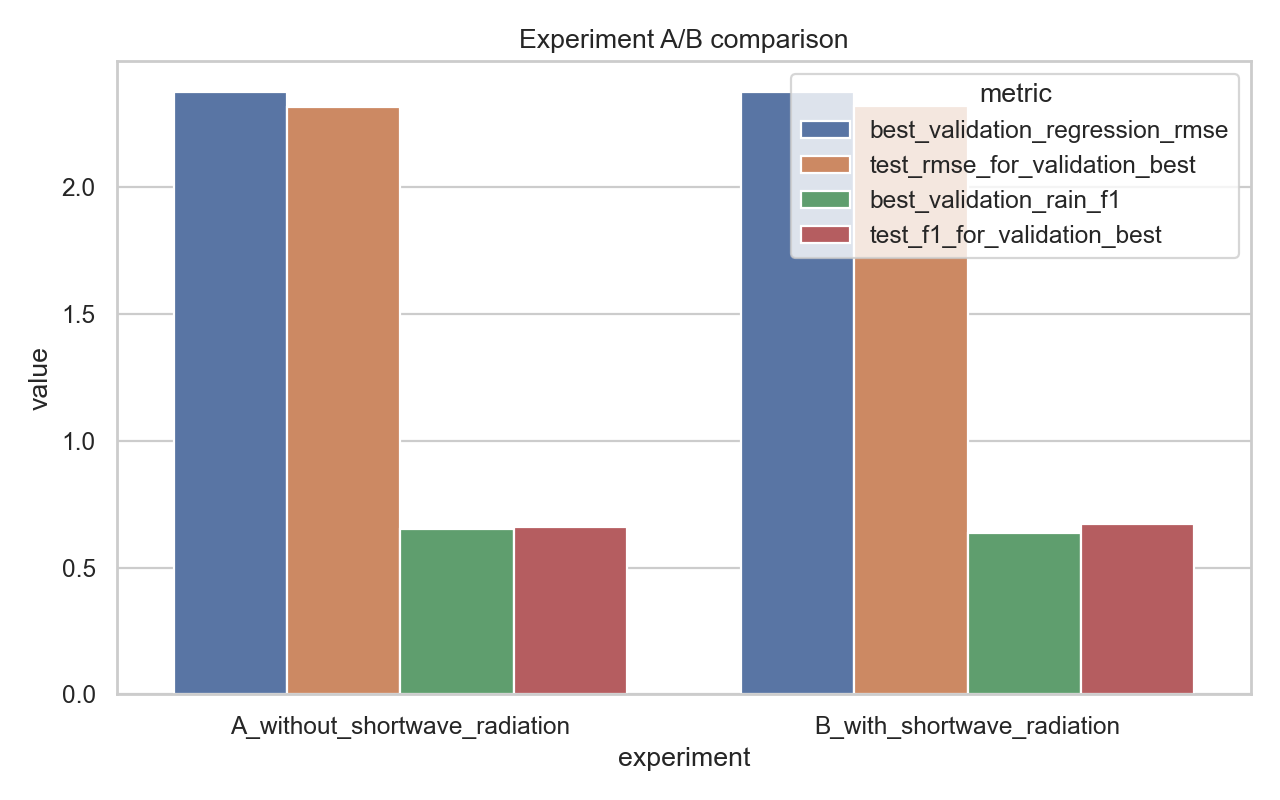
<figcaption aria-hidden="true">So sánh A/B</figcaption>
</figure>


# 8. Kết quả dự báo 7 ngày

## 8.1. Thiết kế direct multi-horizon

Với mỗi horizon `h = 1..7`, target được định nghĩa:

``` text
horizon_temperature = temperature.shift(-h)
horizon_rain = precipitation.shift(-h) > 0
```

Đây là direct multi-horizon forecasting. Mỗi horizon có một cặp mô hình
riêng cho nhiệt độ và mưa. Cách này tránh lỗi tích lũy của phương pháp
recursive, nhưng cần huấn luyện nhiều mô hình hơn.

## 8.2. Phiên bản n_iter=4

| Horizon | Mô hình nhiệt độ | RMSE test | Mô hình mưa        | F1 test | Threshold mưa |
|------------:|----------|------------:|----------|------------:|------------:|
|       1 | LinearRegression |     2,319 | XGBoostClassifier  |   0,652 |          0,20 |
|       2 | LinearRegression |     3,010 | LogisticRegression |   0,653 |          0,40 |
|       3 | XGBoostRegressor |     3,436 | LogisticRegression |   0,638 |          0,45 |
|       4 | XGBoostRegressor |     3,682 | LogisticRegression |   0,617 |          0,40 |
|       5 | XGBoostRegressor |     3,747 | LogisticRegression |   0,587 |          0,50 |
|       6 | XGBoostRegressor |     3,422 | LogisticRegression |   0,597 |          0,40 |
|       7 | XGBoostRegressor |     3,417 | SVM                |   0,634 |          0,40 |

Sai số nhiệt độ tăng khi horizon dài hơn. Đây là xu hướng phù hợp với lý
thuyết dự báo: dự báo càng xa hiện tại thì độ bất định càng lớn. Với
mưa, F1 dao động quanh 0,587-0,653, cho thấy bài toán mưa 7 ngày khó hơn
do tính thưa và biến động nhanh của sự kiện mưa.

## 8.3. Phiên bản n_iter=20

| Horizon | Mô hình nhiệt độ | RMSE validation | RMSE test | Mô hình mưa | F1 validation | F1 test | Threshold |
|---------:|--------|---------:|---------:|--------|---------:|---------:|---------:|
| 1 | XGBoostRegressor | 2,375 | 2,358 | XGBoostClassifier | 0,672 | 0,678 | 0,35 |
| 2 | XGBoostRegressor | 3,100 | 3,061 | LogisticRegression | 0,668 | 0,653 | 0,40 |
| 3 | XGBoostRegressor | 3,337 | 3,283 | LogisticRegression | 0,647 | 0,638 | 0,45 |
| 4 | XGBoostRegressor | 3,459 | 3,415 | LogisticRegression | 0,641 | 0,617 | 0,40 |
| 5 | XGBoostRegressor | 3,436 | 3,512 | LogisticRegression | 0,628 | 0,587 | 0,50 |
| 6 | XGBoostRegressor | 3,458 | 3,262 | XGBoostClassifier | 0,615 | 0,620 | 0,45 |
| 7 | XGBoostRegressor | 3,516 | 3,220 | SVM | 0,620 | 0,634 | 0,40 |

Trong phiên bản `n_iter=20`, XGBoostRegressor được chọn cho toàn bộ 7
horizon nhiệt độ. Điều này cho thấy khi dự báo xa hơn một ngày, quan hệ
giữa input hiện tại/quá khứ và nhiệt độ tương lai không còn tuyến tính
đơn giản như bài toán ngày kế tiếp. XGBoost có khả năng mô hình hóa
tương tác phi tuyến giữa mùa, độ ẩm, mây, bức xạ, lag và rolling, nên
phù hợp hơn với bài toán đa horizon.

<figure>
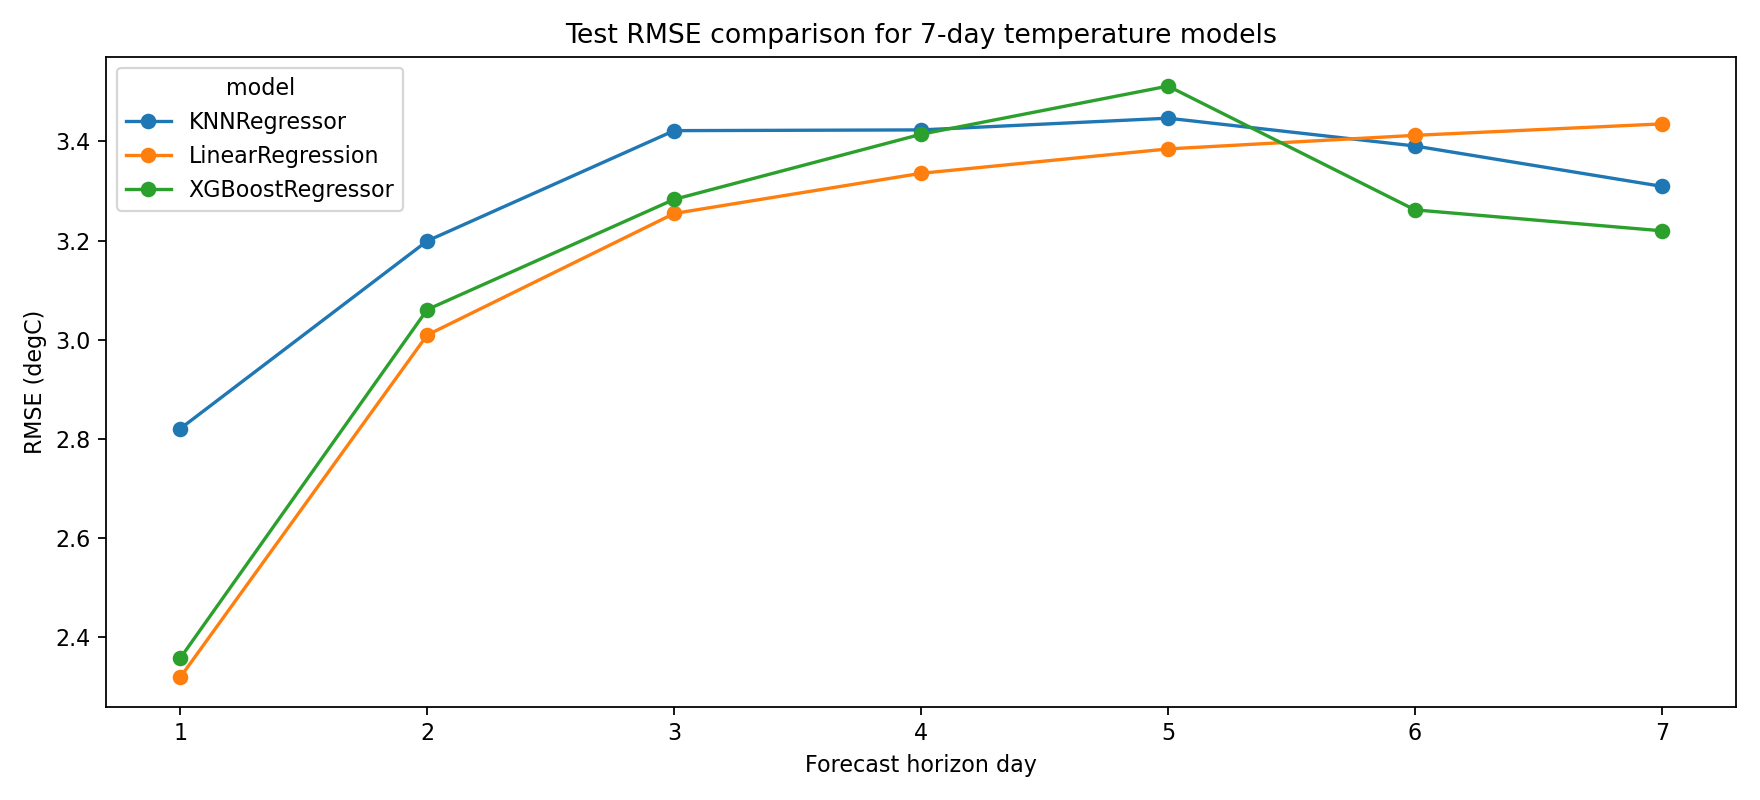
<figcaption aria-hidden="true">Temperature model comparison line
chart</figcaption>
</figure>

<figure>
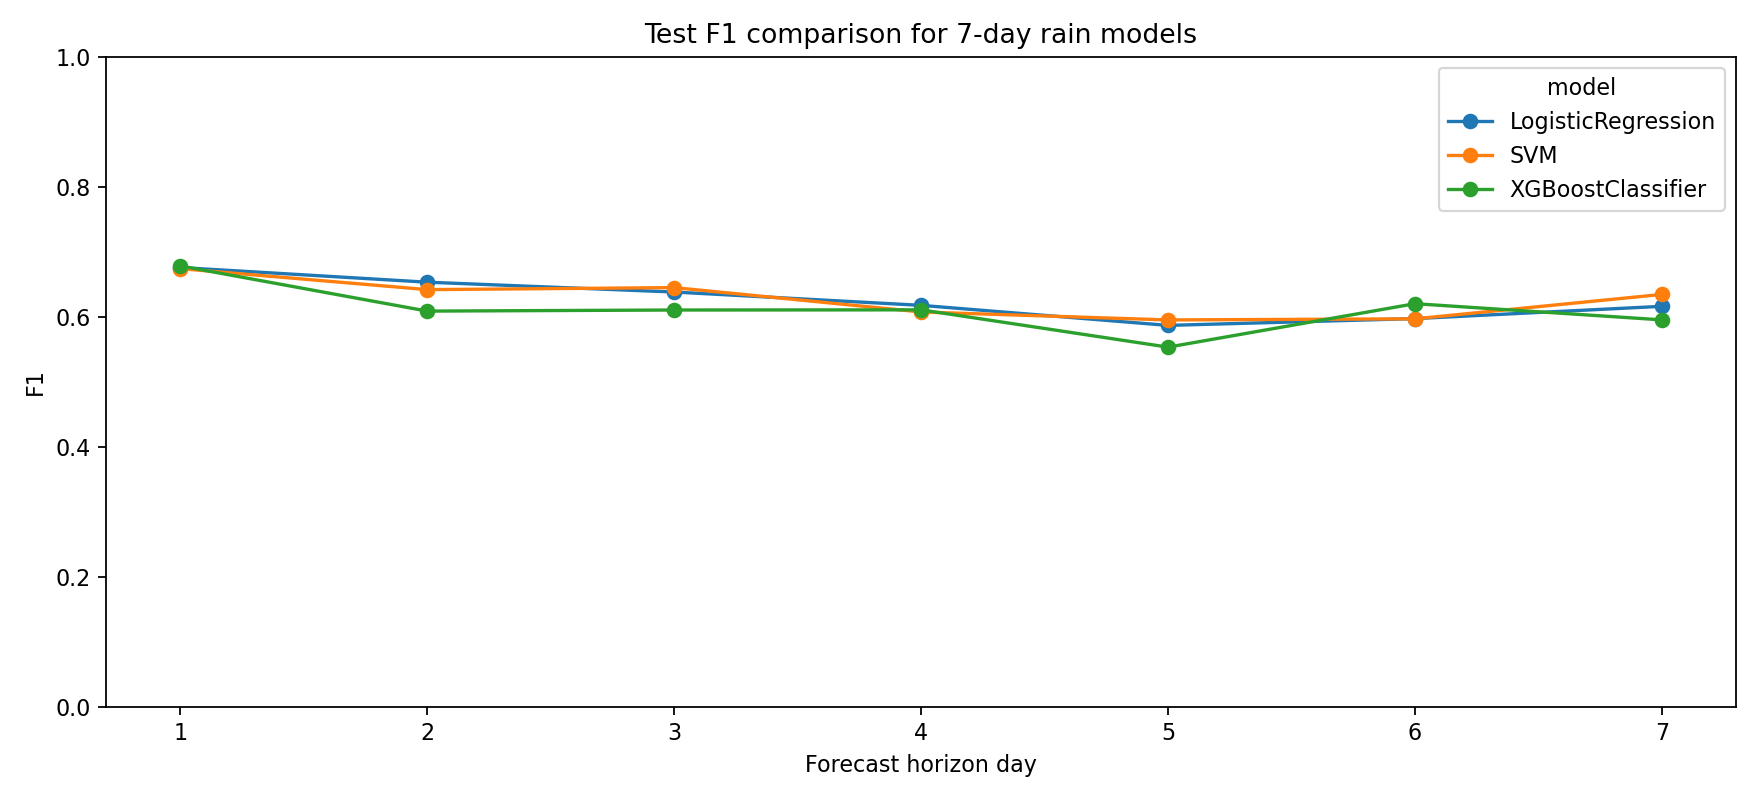
<figcaption aria-hidden="true">Rain model comparison line
chart</figcaption>
</figure>

## 8.4. So sánh n_iter=4 và n_iter=20

| Chỉ số                              | n_iter=4 | n_iter=20 | Diễn giải           |
|----------------|--------------------:|--------------------:|----------------|
| Mean selected temperature test RMSE |    3,290 |     3,159 | Thấp hơn là tốt hơn |
| Mean selected rain test F1          |    0,625 |     0,632 | Cao hơn là tốt hơn  |

| Horizon | RMSE n_iter=4 | RMSE n_iter=20 | Delta RMSE | F1 n_iter=4 | F1 n_iter=20 | Delta F1 |
|----------:|----------:|----------:|----------:|----------:|----------:|----------:|
| 1 | 2,319 | 2,358 | +0,039 | 0,652 | 0,678 | +0,026 |
| 2 | 3,010 | 3,061 | +0,051 | 0,653 | 0,653 | 0,000 |
| 3 | 3,436 | 3,283 | -0,153 | 0,638 | 0,638 | 0,000 |
| 4 | 3,682 | 3,415 | -0,267 | 0,617 | 0,617 | 0,000 |
| 5 | 3,747 | 3,512 | -0,235 | 0,587 | 0,587 | 0,000 |
| 6 | 3,422 | 3,262 | -0,160 | 0,597 | 0,620 | +0,023 |
| 7 | 3,417 | 3,220 | -0,198 | 0,634 | 0,634 | 0,000 |

<figure>
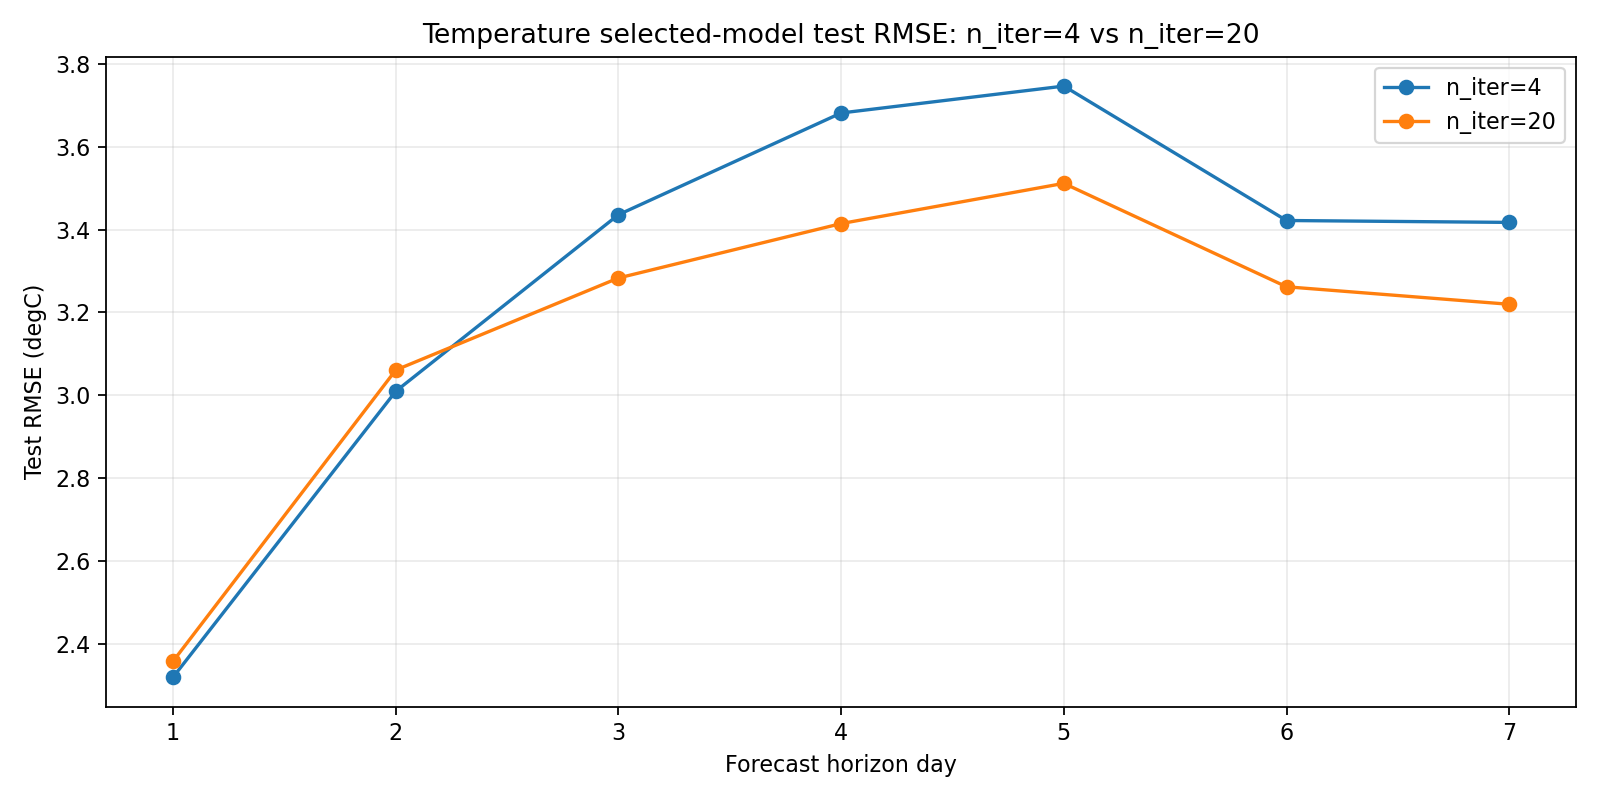
<figcaption aria-hidden="true">So sánh RMSE nhiệt độ giữa n_iter=4 và
n_iter=20</figcaption>
</figure>

<figure>
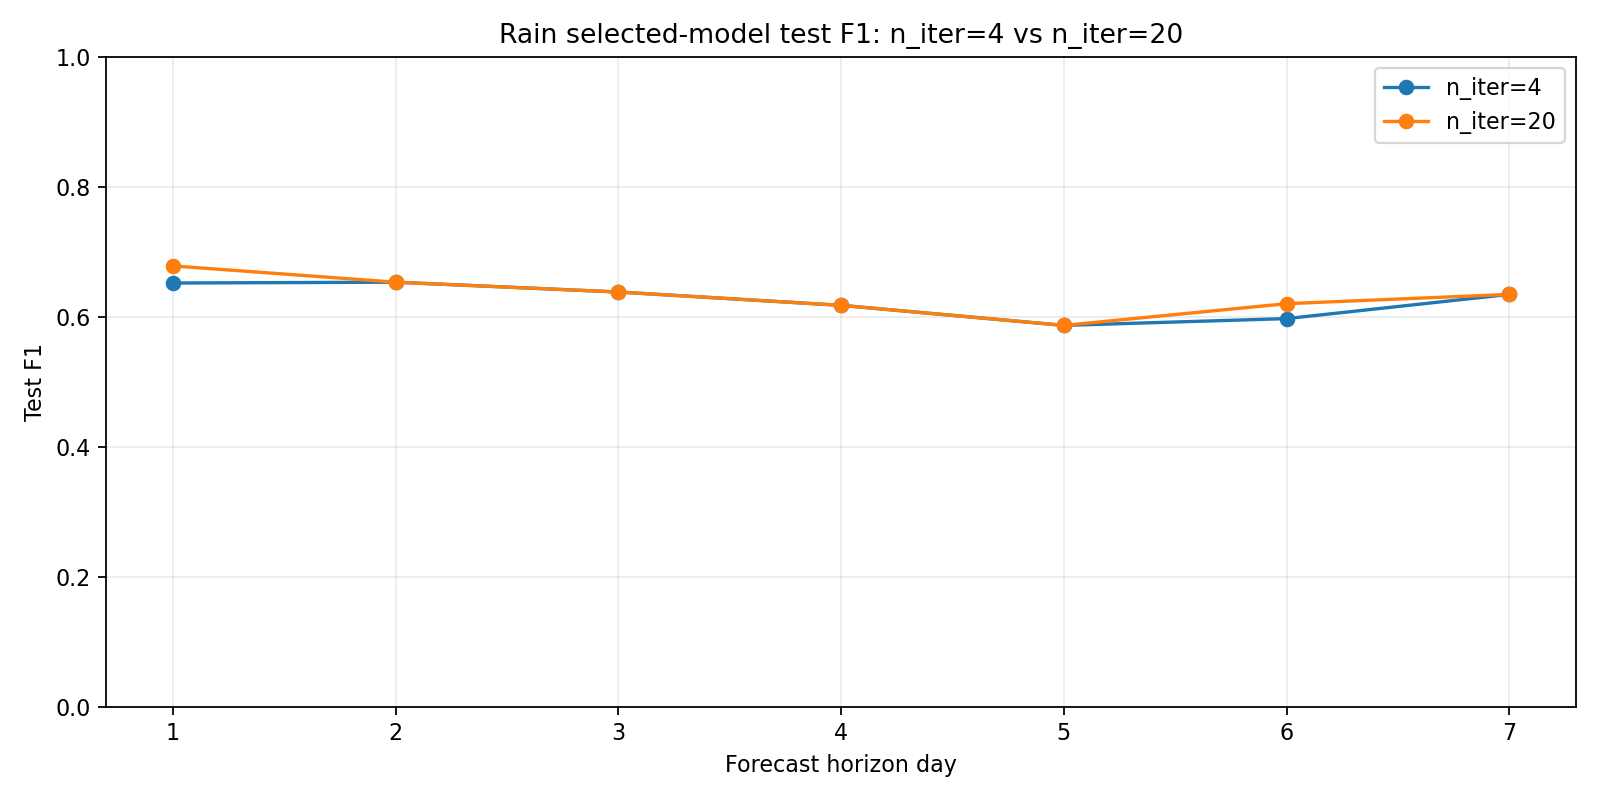
<figcaption aria-hidden="true">So sánh F1 mưa giữa n_iter=4 và
n_iter=20</figcaption>
</figure>

Phiên bản `n_iter=20` không tốt hơn ở mọi horizon. Ở horizon 1 và 2,
RMSE nhiệt độ tăng nhẹ. Tuy nhiên, từ horizon 3 đến 7, RMSE giảm rõ hơn,
làm RMSE trung bình toàn bộ 7 ngày thấp hơn. Với mưa, cải thiện tập
trung ở horizon 1 và 6; các horizon khác gần như không đổi. Như vậy,
tuning sâu hơn có ích nhưng không phải yếu tố duy nhất quyết định chất
lượng dự báo.


# 9. Tham số tốt nhất và diễn giải tuning

## 9.1. Tham số tốt nhất của phiên bản n_iter=20

| Horizon | Task | Model | CV metric | Best params |
|----------------:|-------------|-------------|----------------:|-------------|
| 1 | temperature | XGBoostRegressor | RMSE 2,896 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 1 | rain | XGBoostClassifier | F1 0,638 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 2 | temperature | XGBoostRegressor | RMSE 3,546 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 2 | rain | LogisticRegression | F1 0,579 | C=0,01 |
| 3 | temperature | XGBoostRegressor | RMSE 3,988 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 3 | rain | LogisticRegression | F1 0,562 | C=0,01 |
| 4 | temperature | XGBoostRegressor | RMSE 4,138 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 4 | rain | LogisticRegression | F1 0,546 | C=0,01 |
| 5 | temperature | XGBoostRegressor | RMSE 4,004 | learning_rate=0,12177; max_depth=4; n_estimators=152 |
| 5 | rain | LogisticRegression | F1 0,562 | C=0,01 |
| 6 | temperature | XGBoostRegressor | RMSE 3,952 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 6 | rain | XGBoostClassifier | F1 0,507 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 7 | temperature | XGBoostRegressor | RMSE 3,837 | learning_rate=0,01597; max_depth=4; n_estimators=443 |
| 7 | rain | SVM | F1 0,549 | C=0,1; kernel=linear |

Bảng trên trình bày cấu hình tốt nhất trong search space của model được
chọn tại từng horizon. Cần phân biệt hai giai đoạn: `RandomizedSearchCV`
chọn cấu hình tốt nhất cho từng model trên training cross-validation;
sau đó validation set chọn model cuối cùng giữa các candidate model đã
được tuning.

## 9.2. Biểu đồ hyperparameter tuning từng model

<figure>
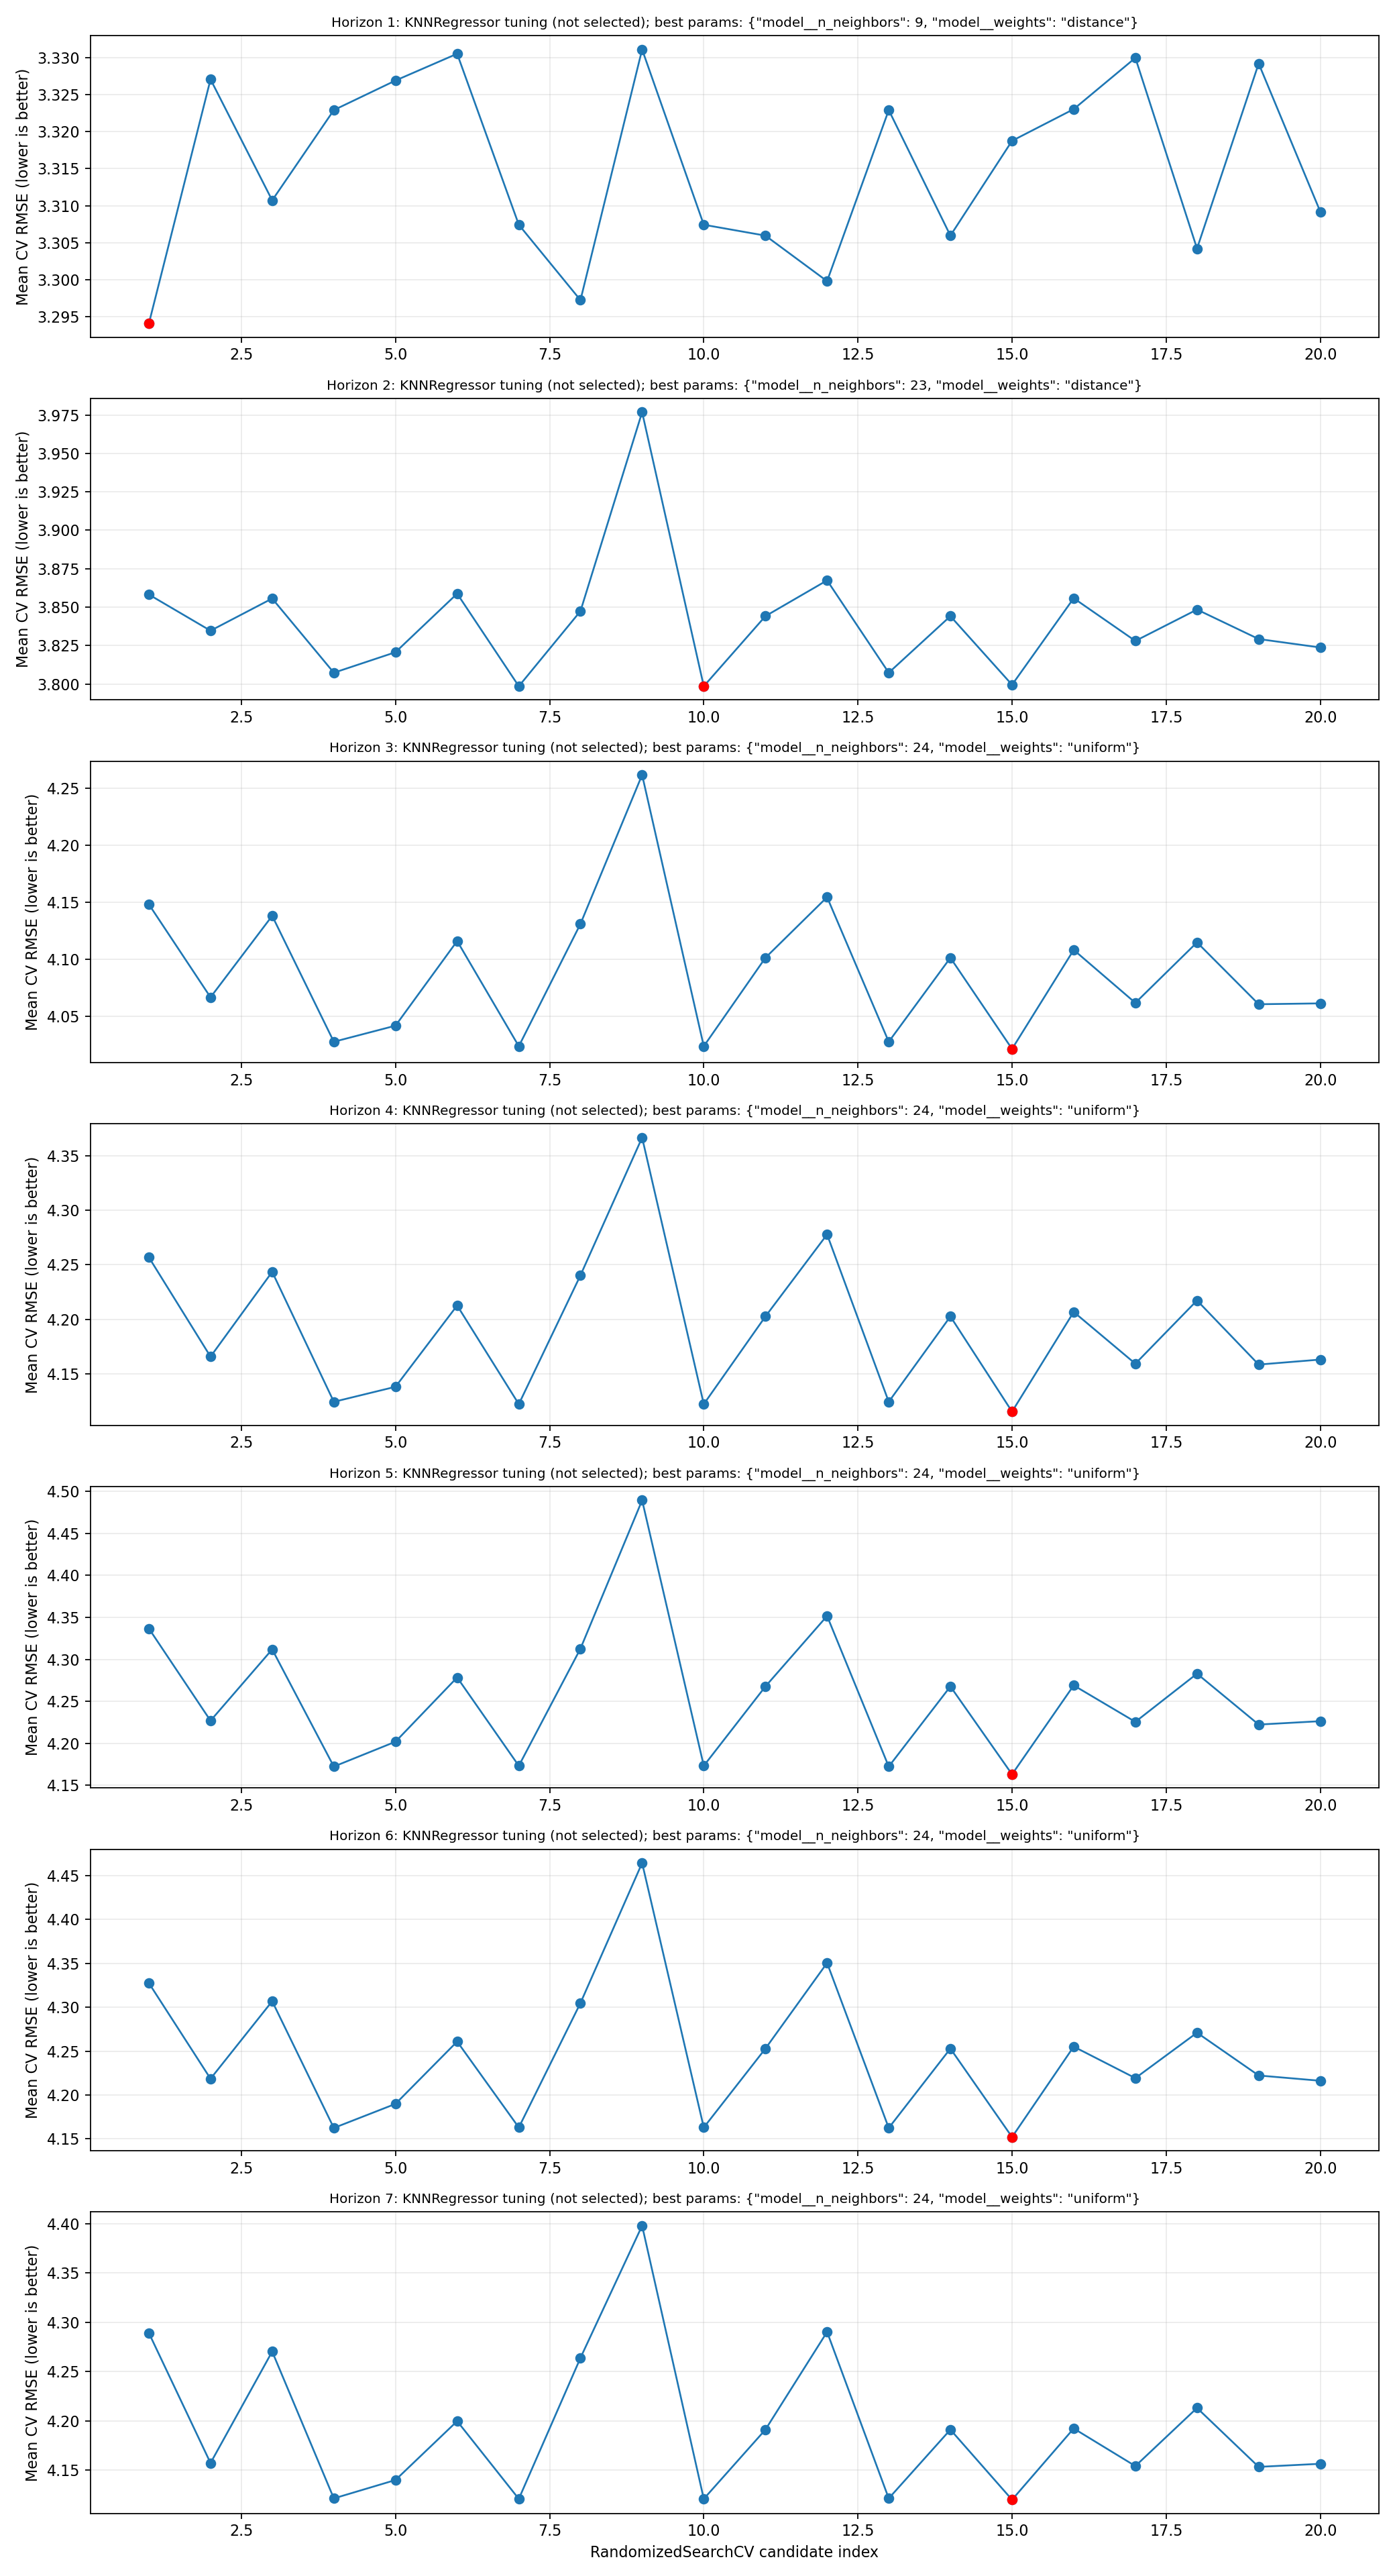
<figcaption aria-hidden="true">KNN tuning</figcaption>
</figure>

<figure>
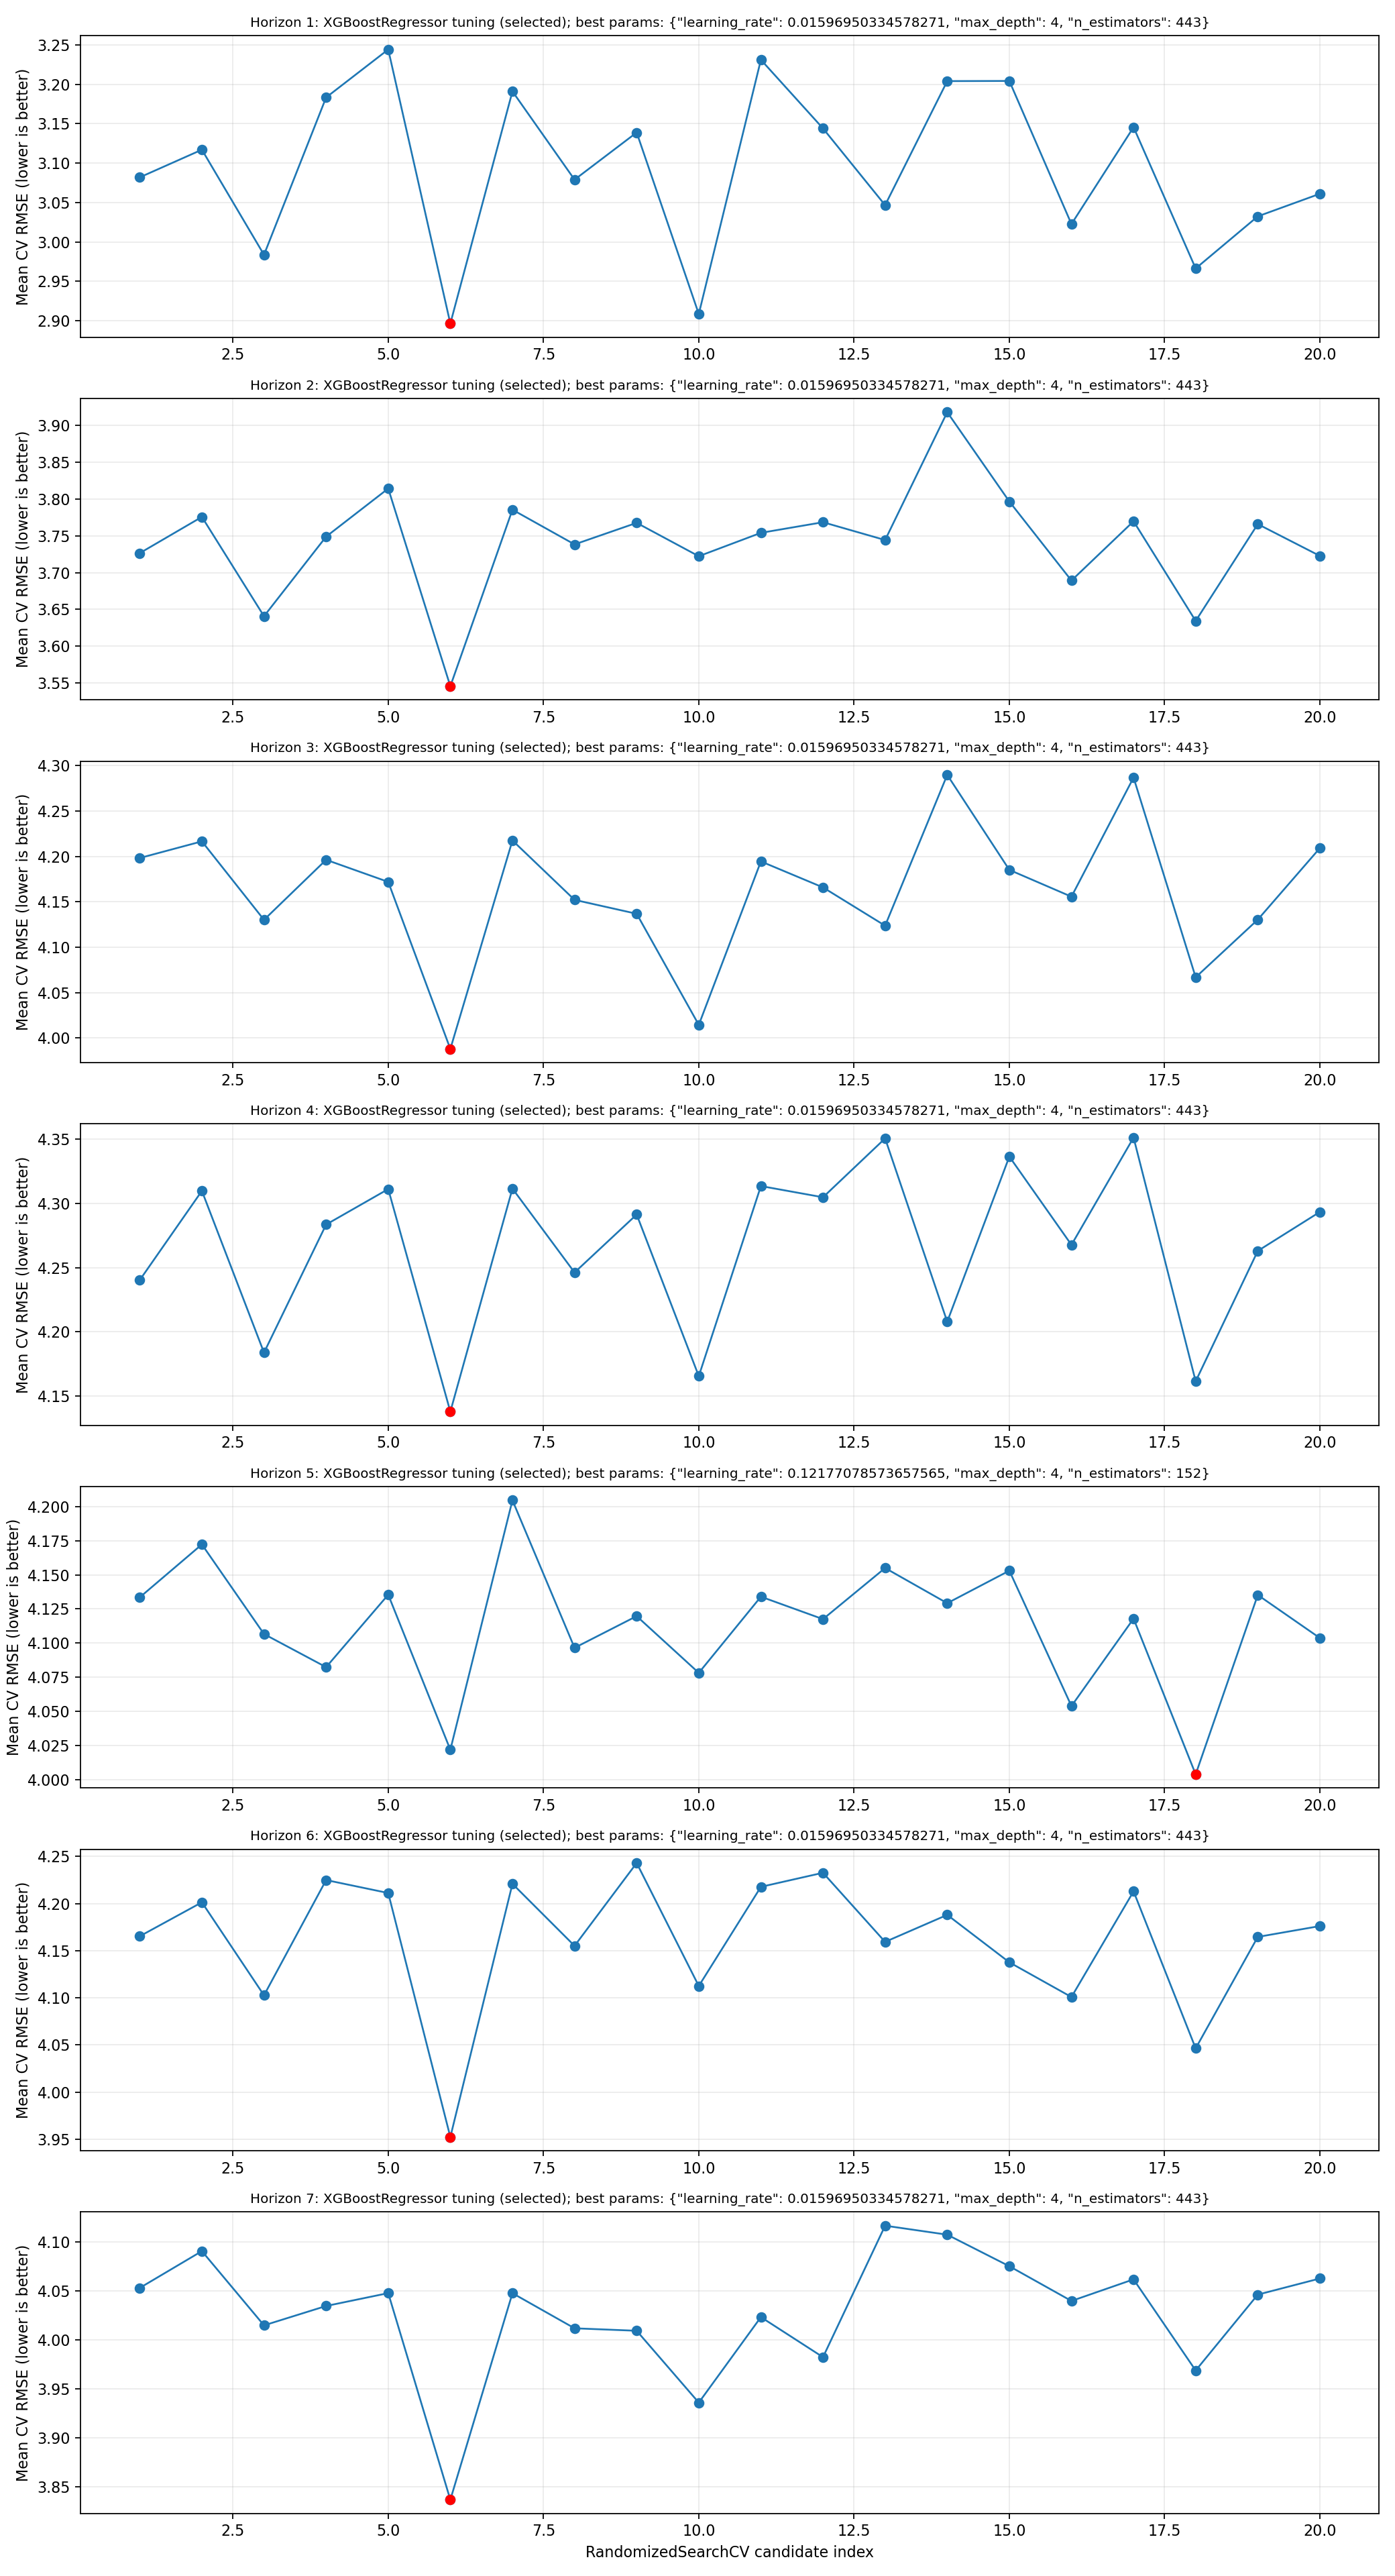
<figcaption aria-hidden="true">XGBoost Regressor tuning</figcaption>
</figure>

<figure>
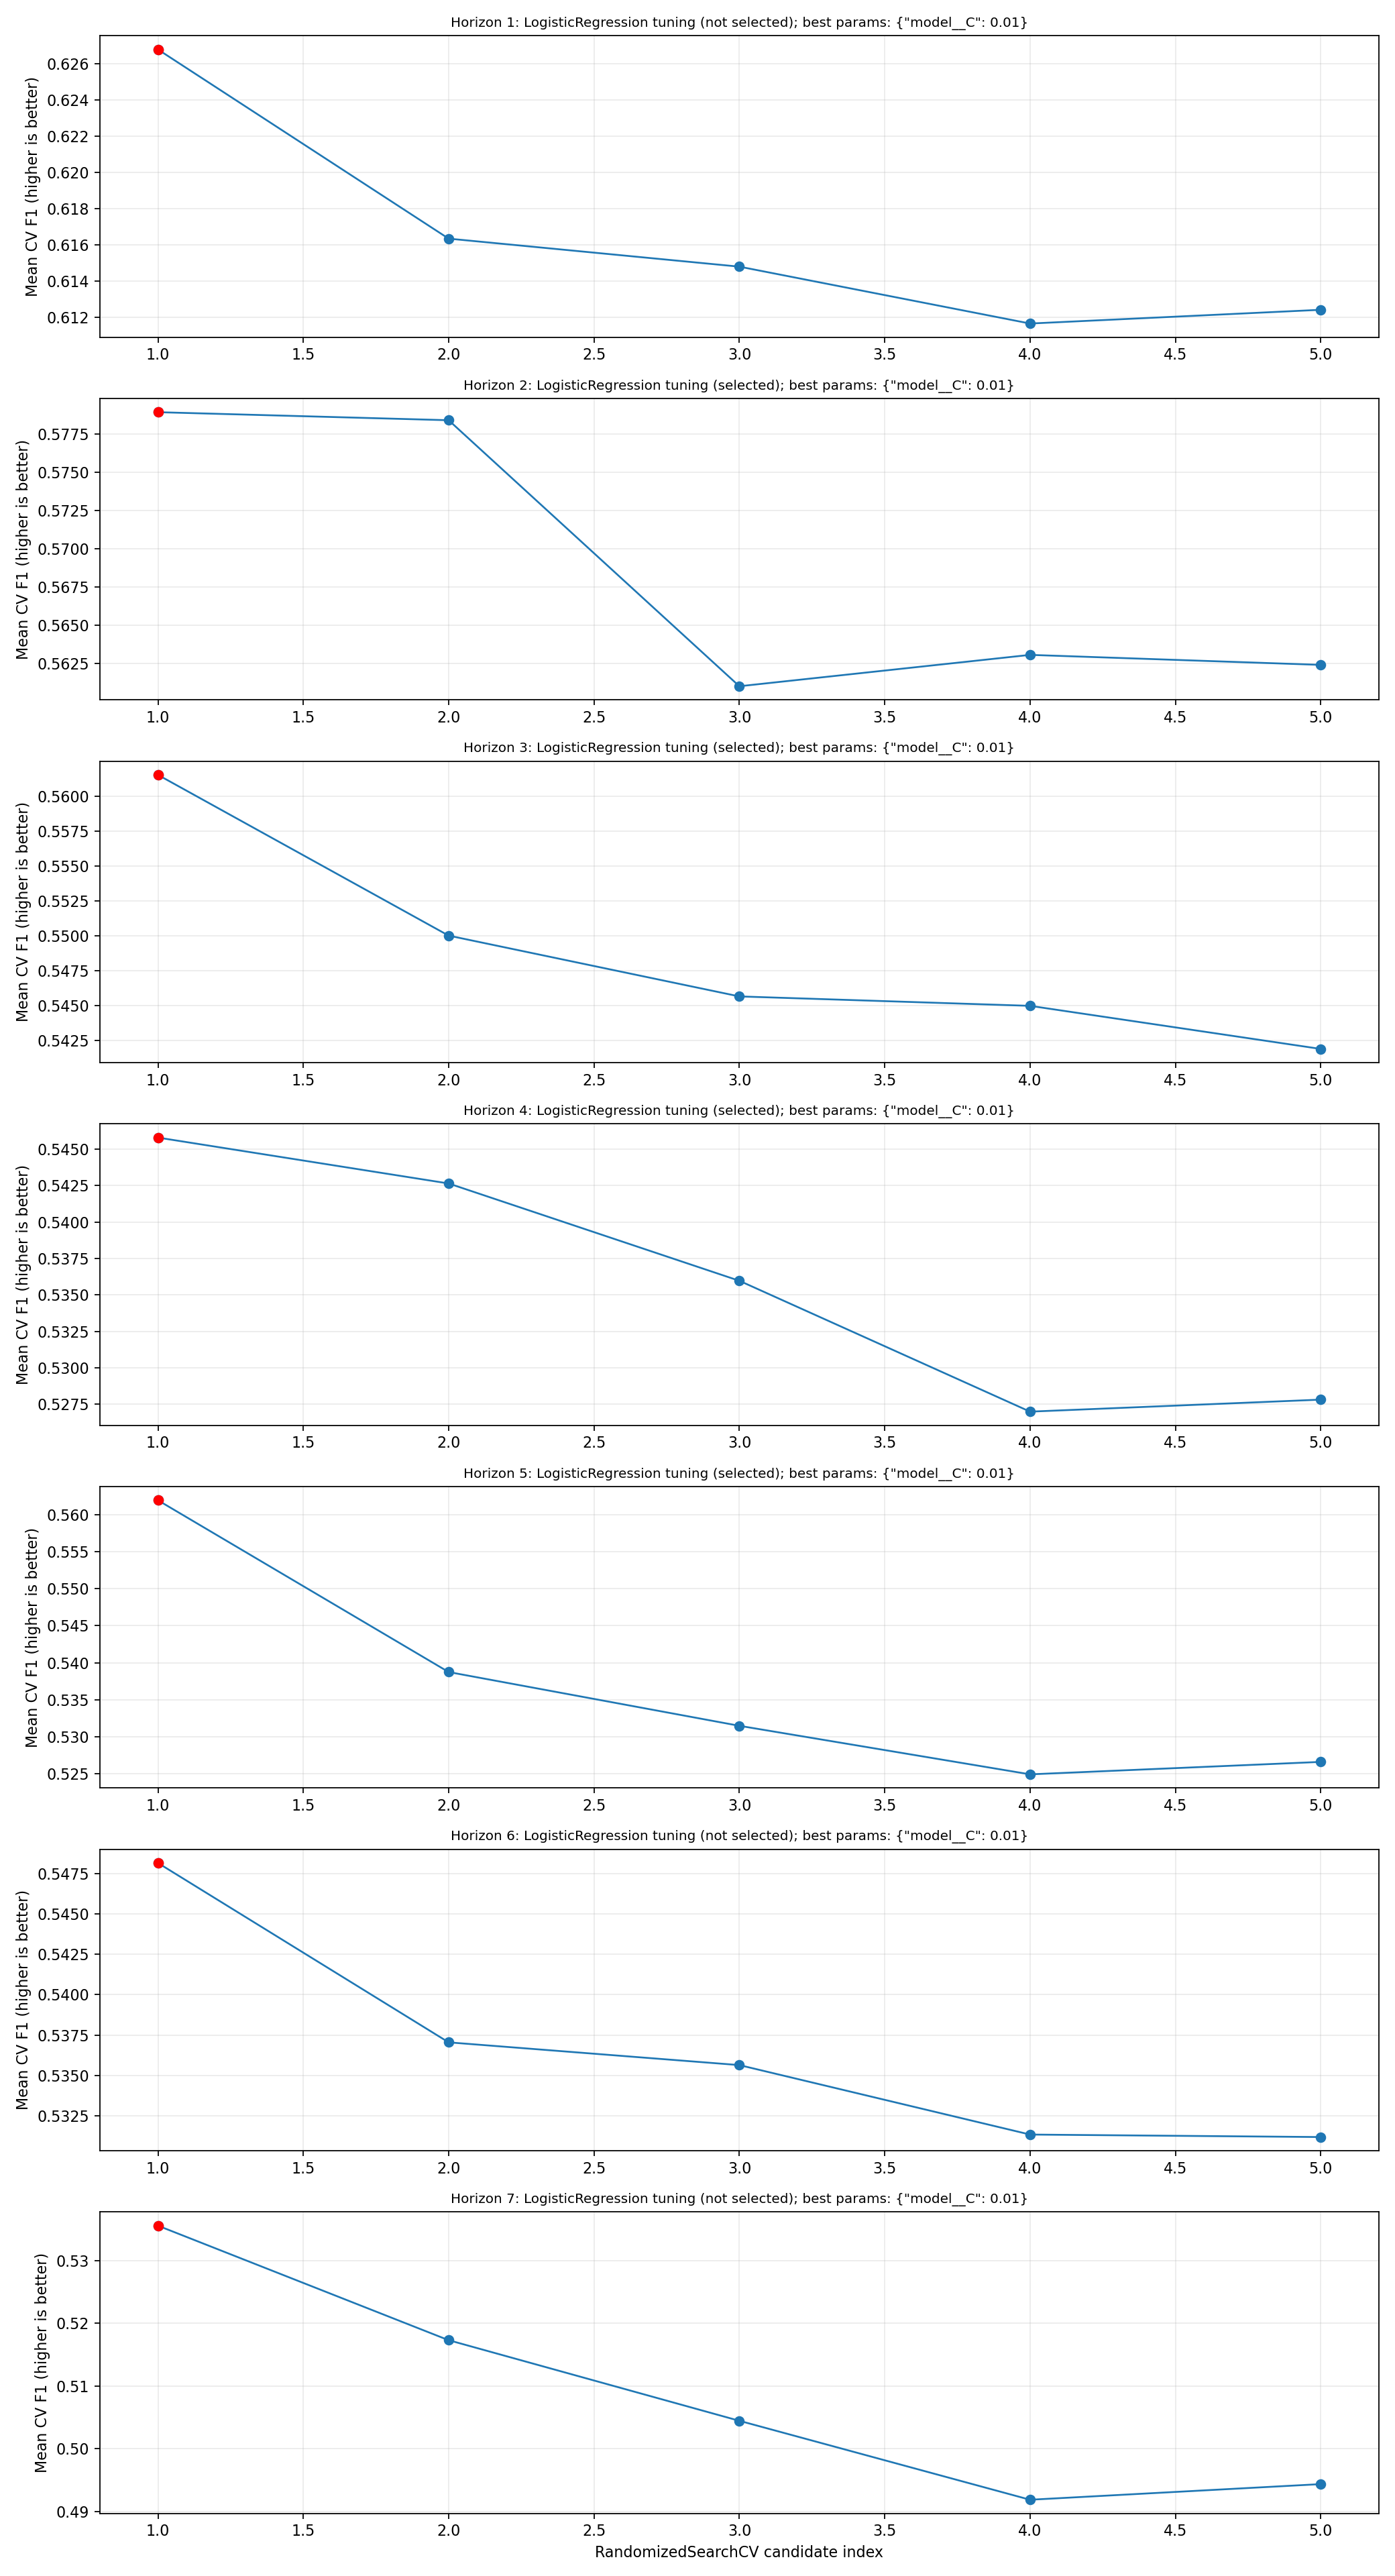
<figcaption aria-hidden="true">Logistic Regression tuning</figcaption>
</figure>

<figure>
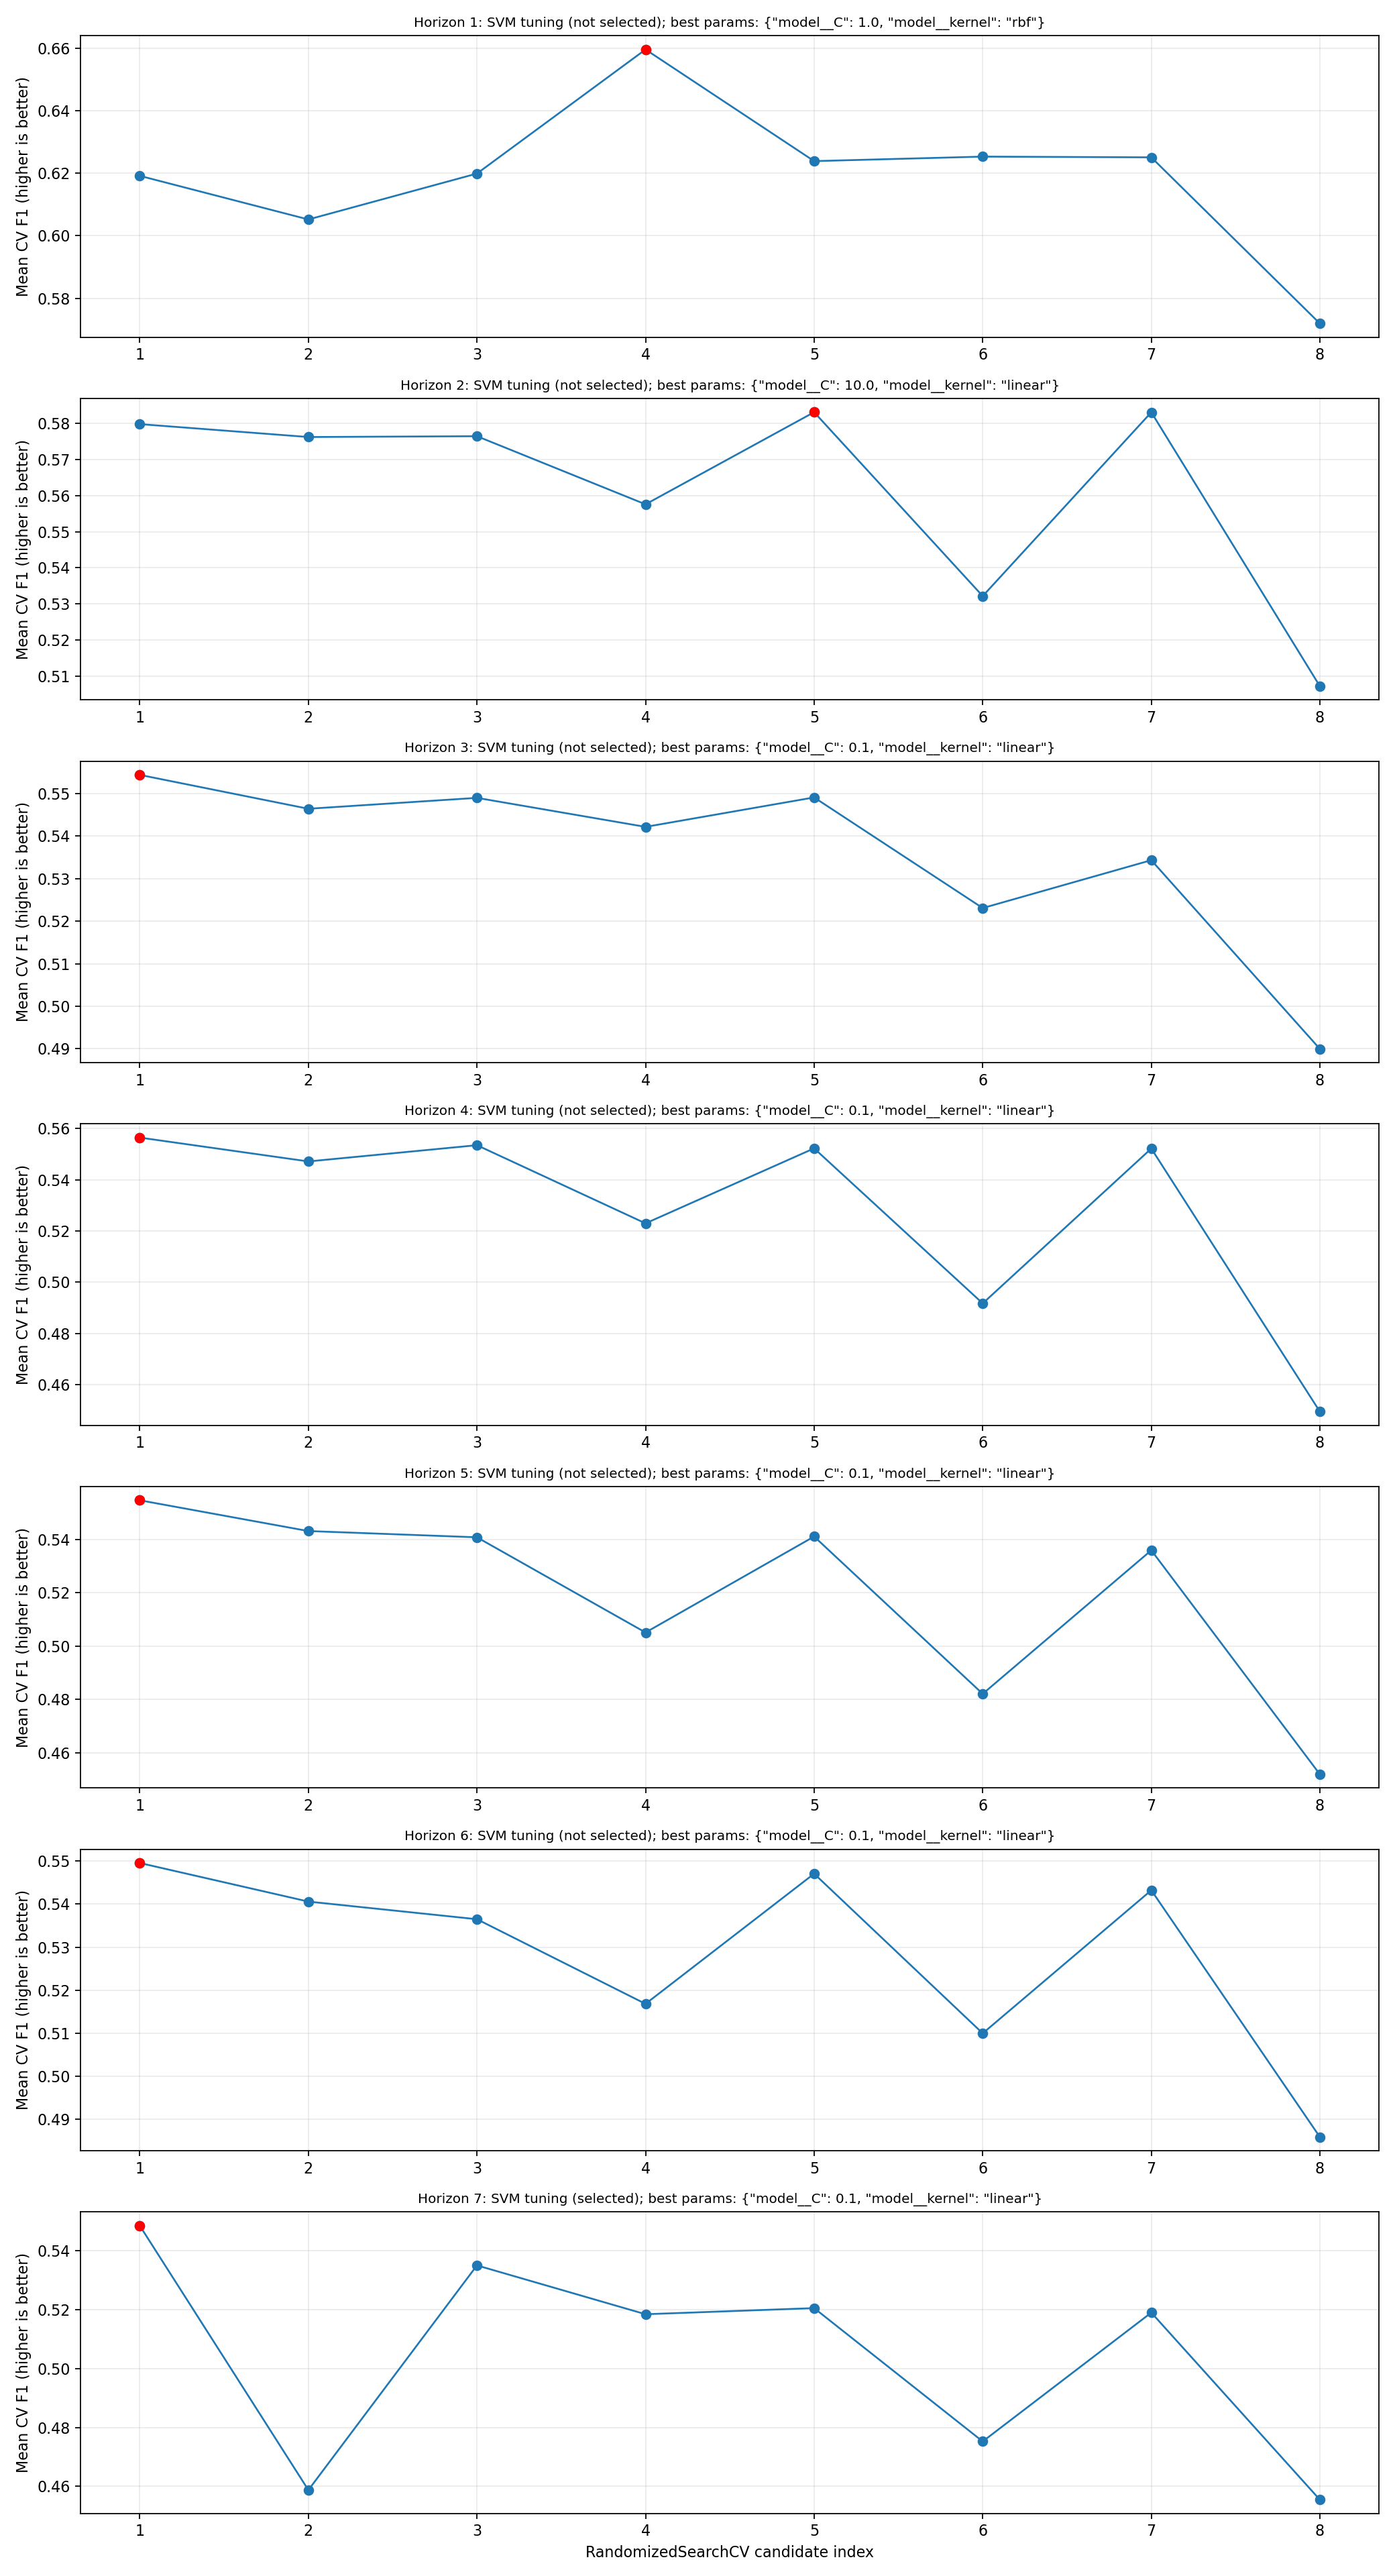
<figcaption aria-hidden="true">SVM tuning</figcaption>
</figure>

<figure>
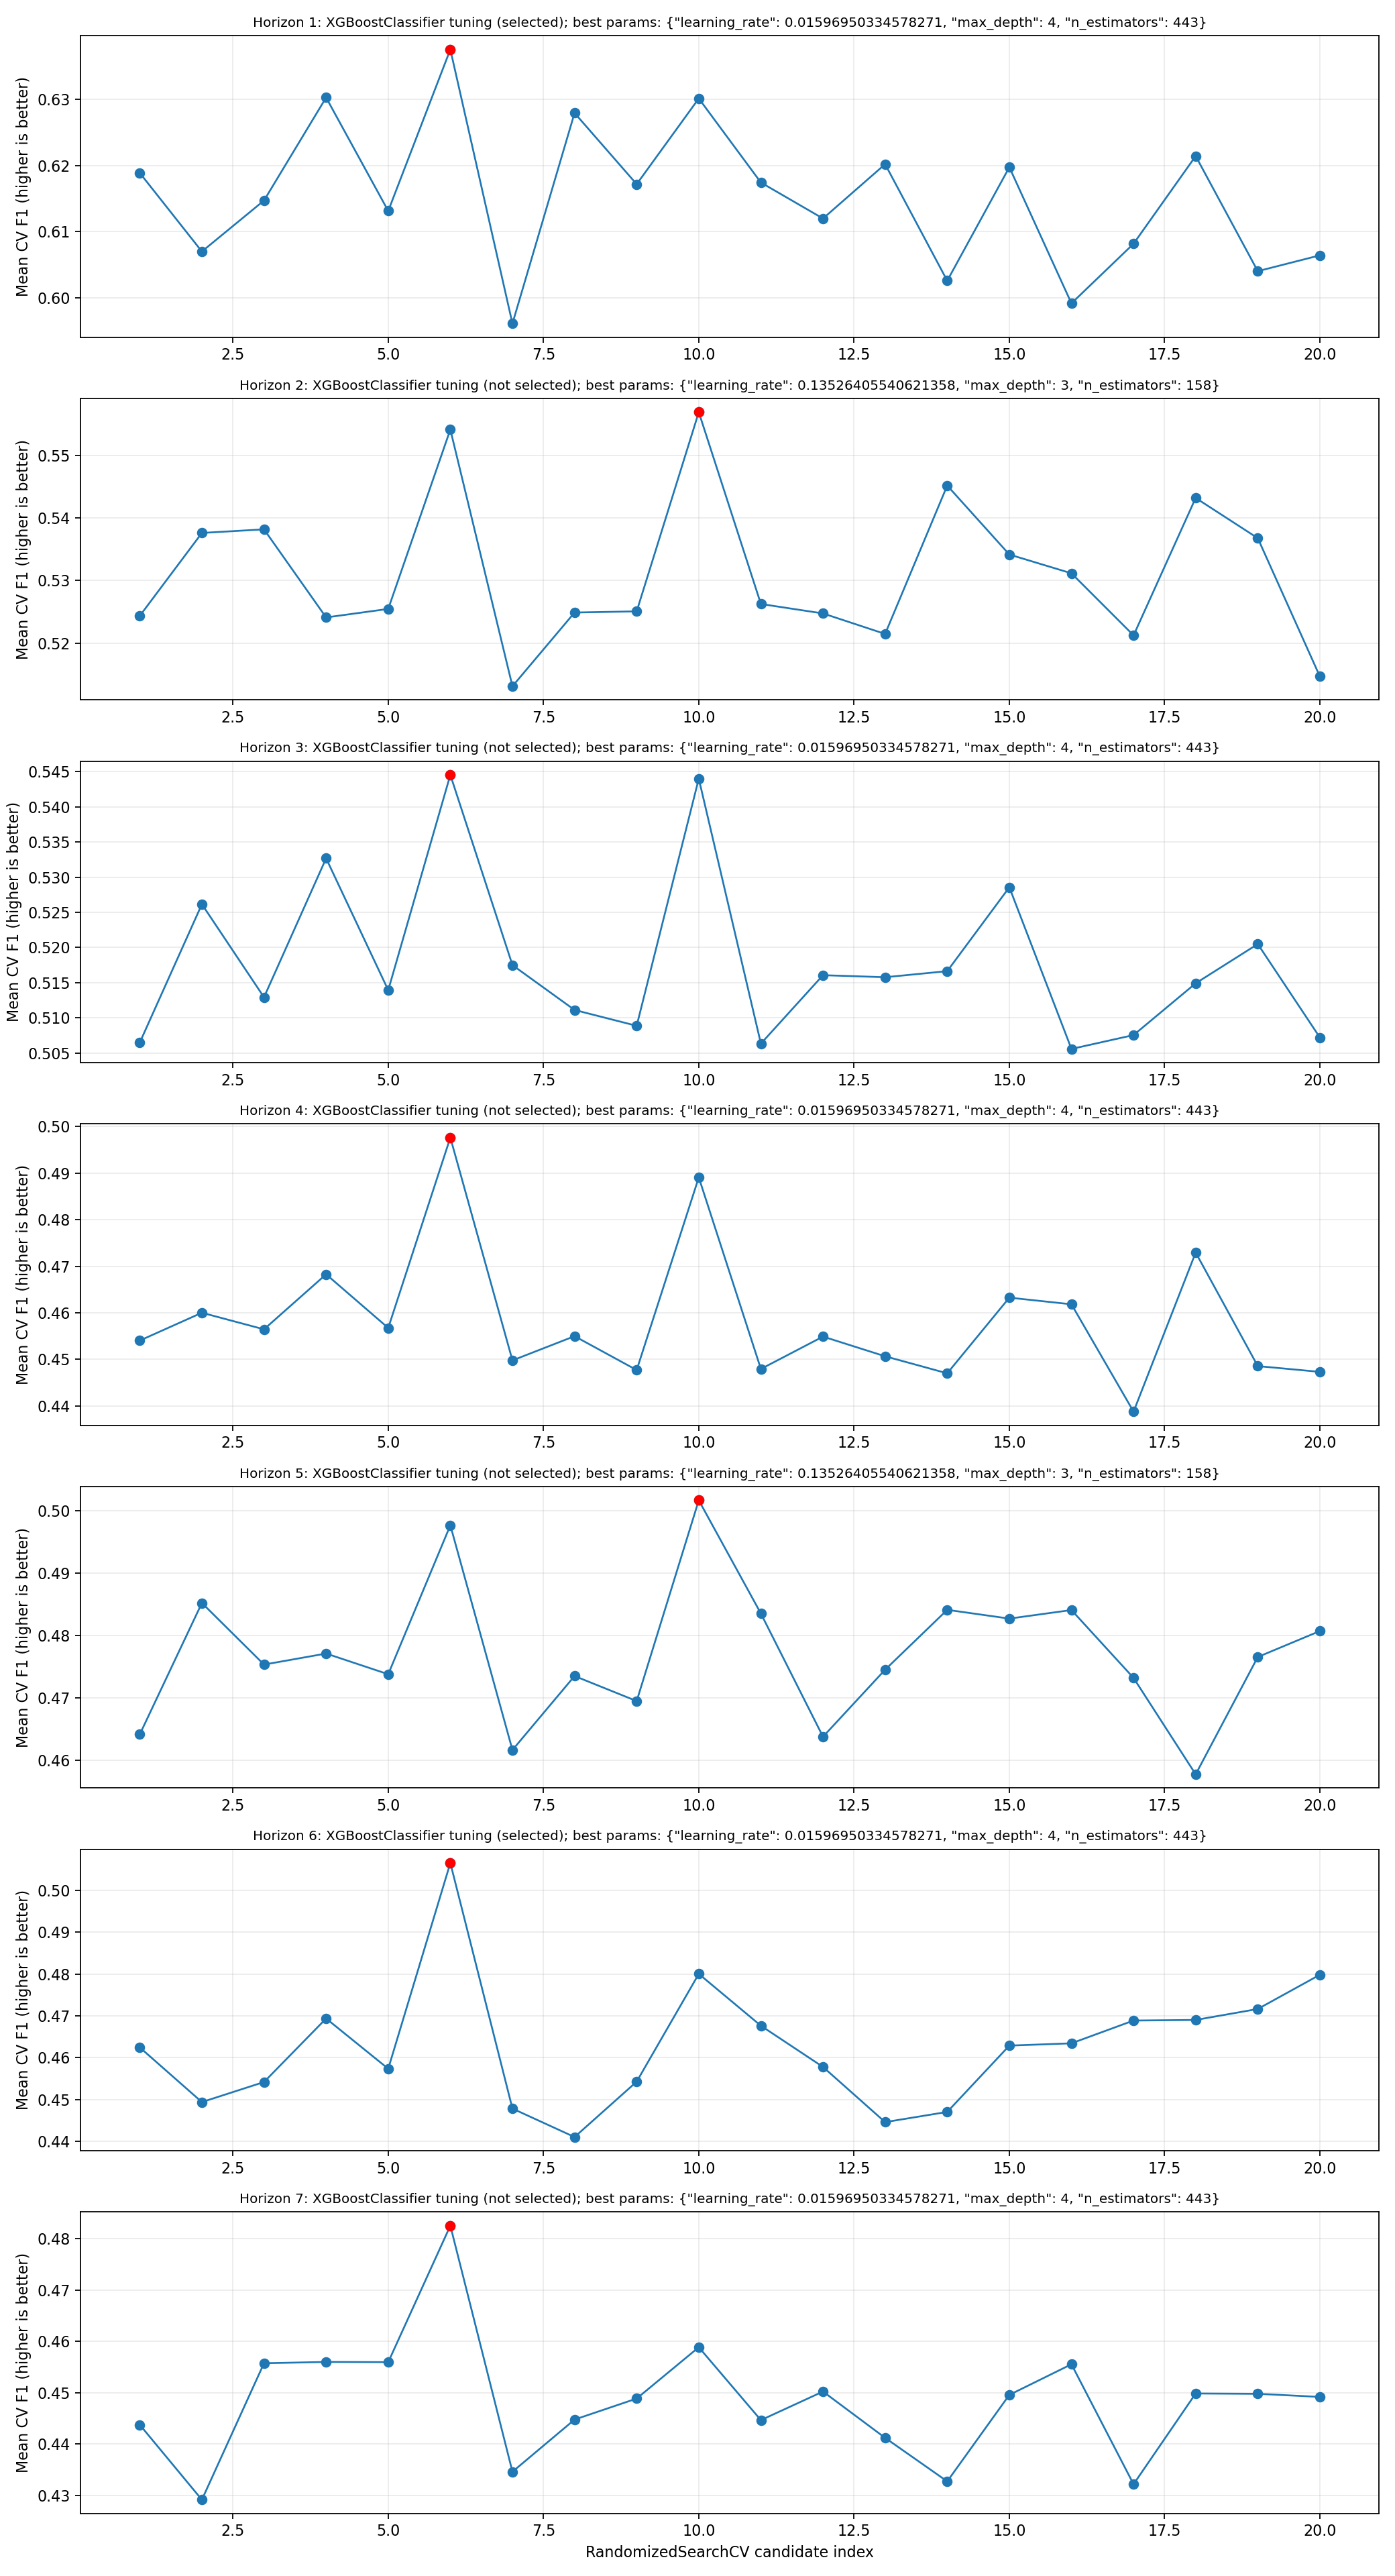
<figcaption aria-hidden="true">XGBoost Classifier tuning</figcaption>
</figure>

Các biểu đồ này cho thấy mỗi điểm tương ứng một cấu hình được thử bởi
`RandomizedSearchCV`. Với hồi quy, trục tung là CV RMSE nên càng thấp
càng tốt. Với phân loại, trục tung là CV F1 nên càng cao càng tốt. Việc
so sánh đường tuning giúp thấy rõ model nào nhạy với cấu hình tham số và
model nào ổn định hơn.

<figure>
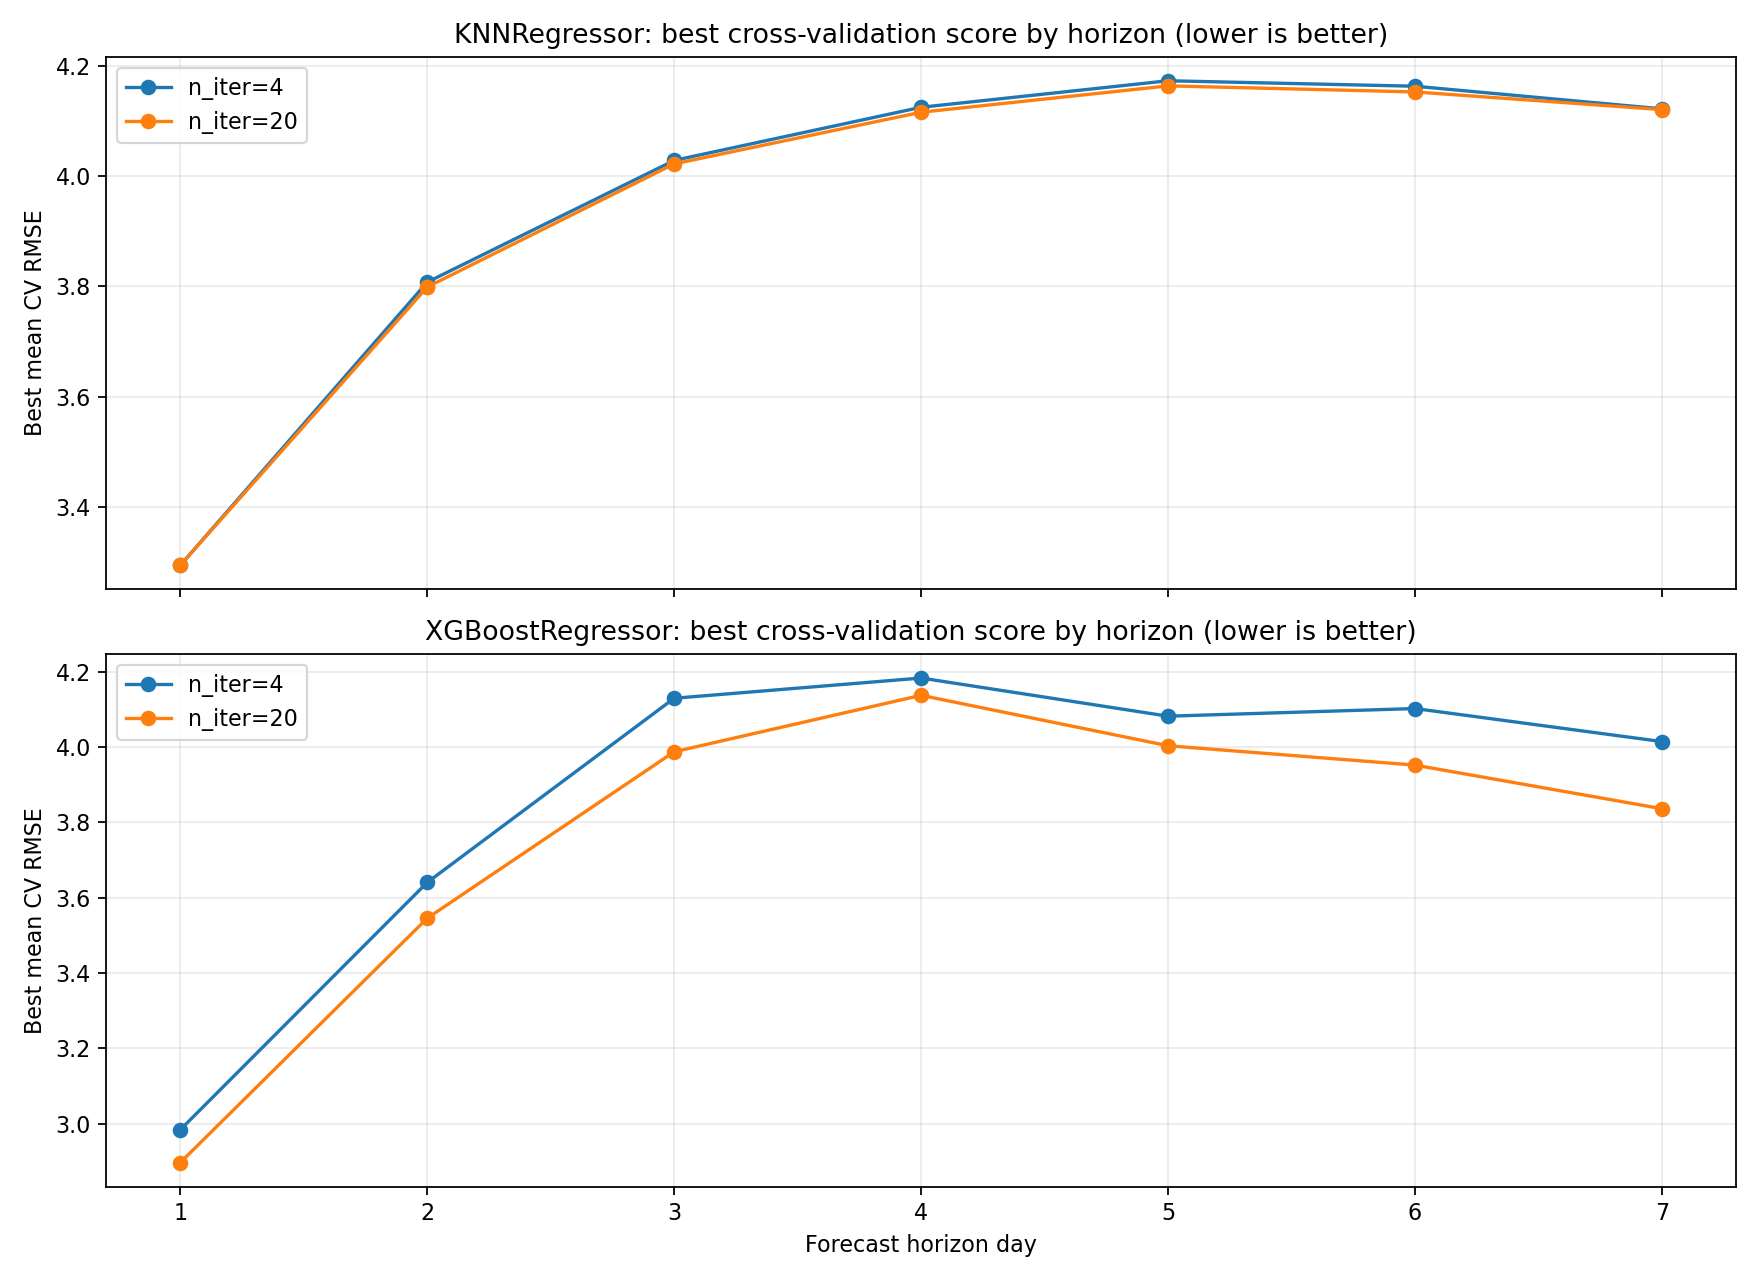
<figcaption aria-hidden="true">So sánh tuning CV RMSE theo từng model
nhiệt độ</figcaption>
</figure>

<figure>
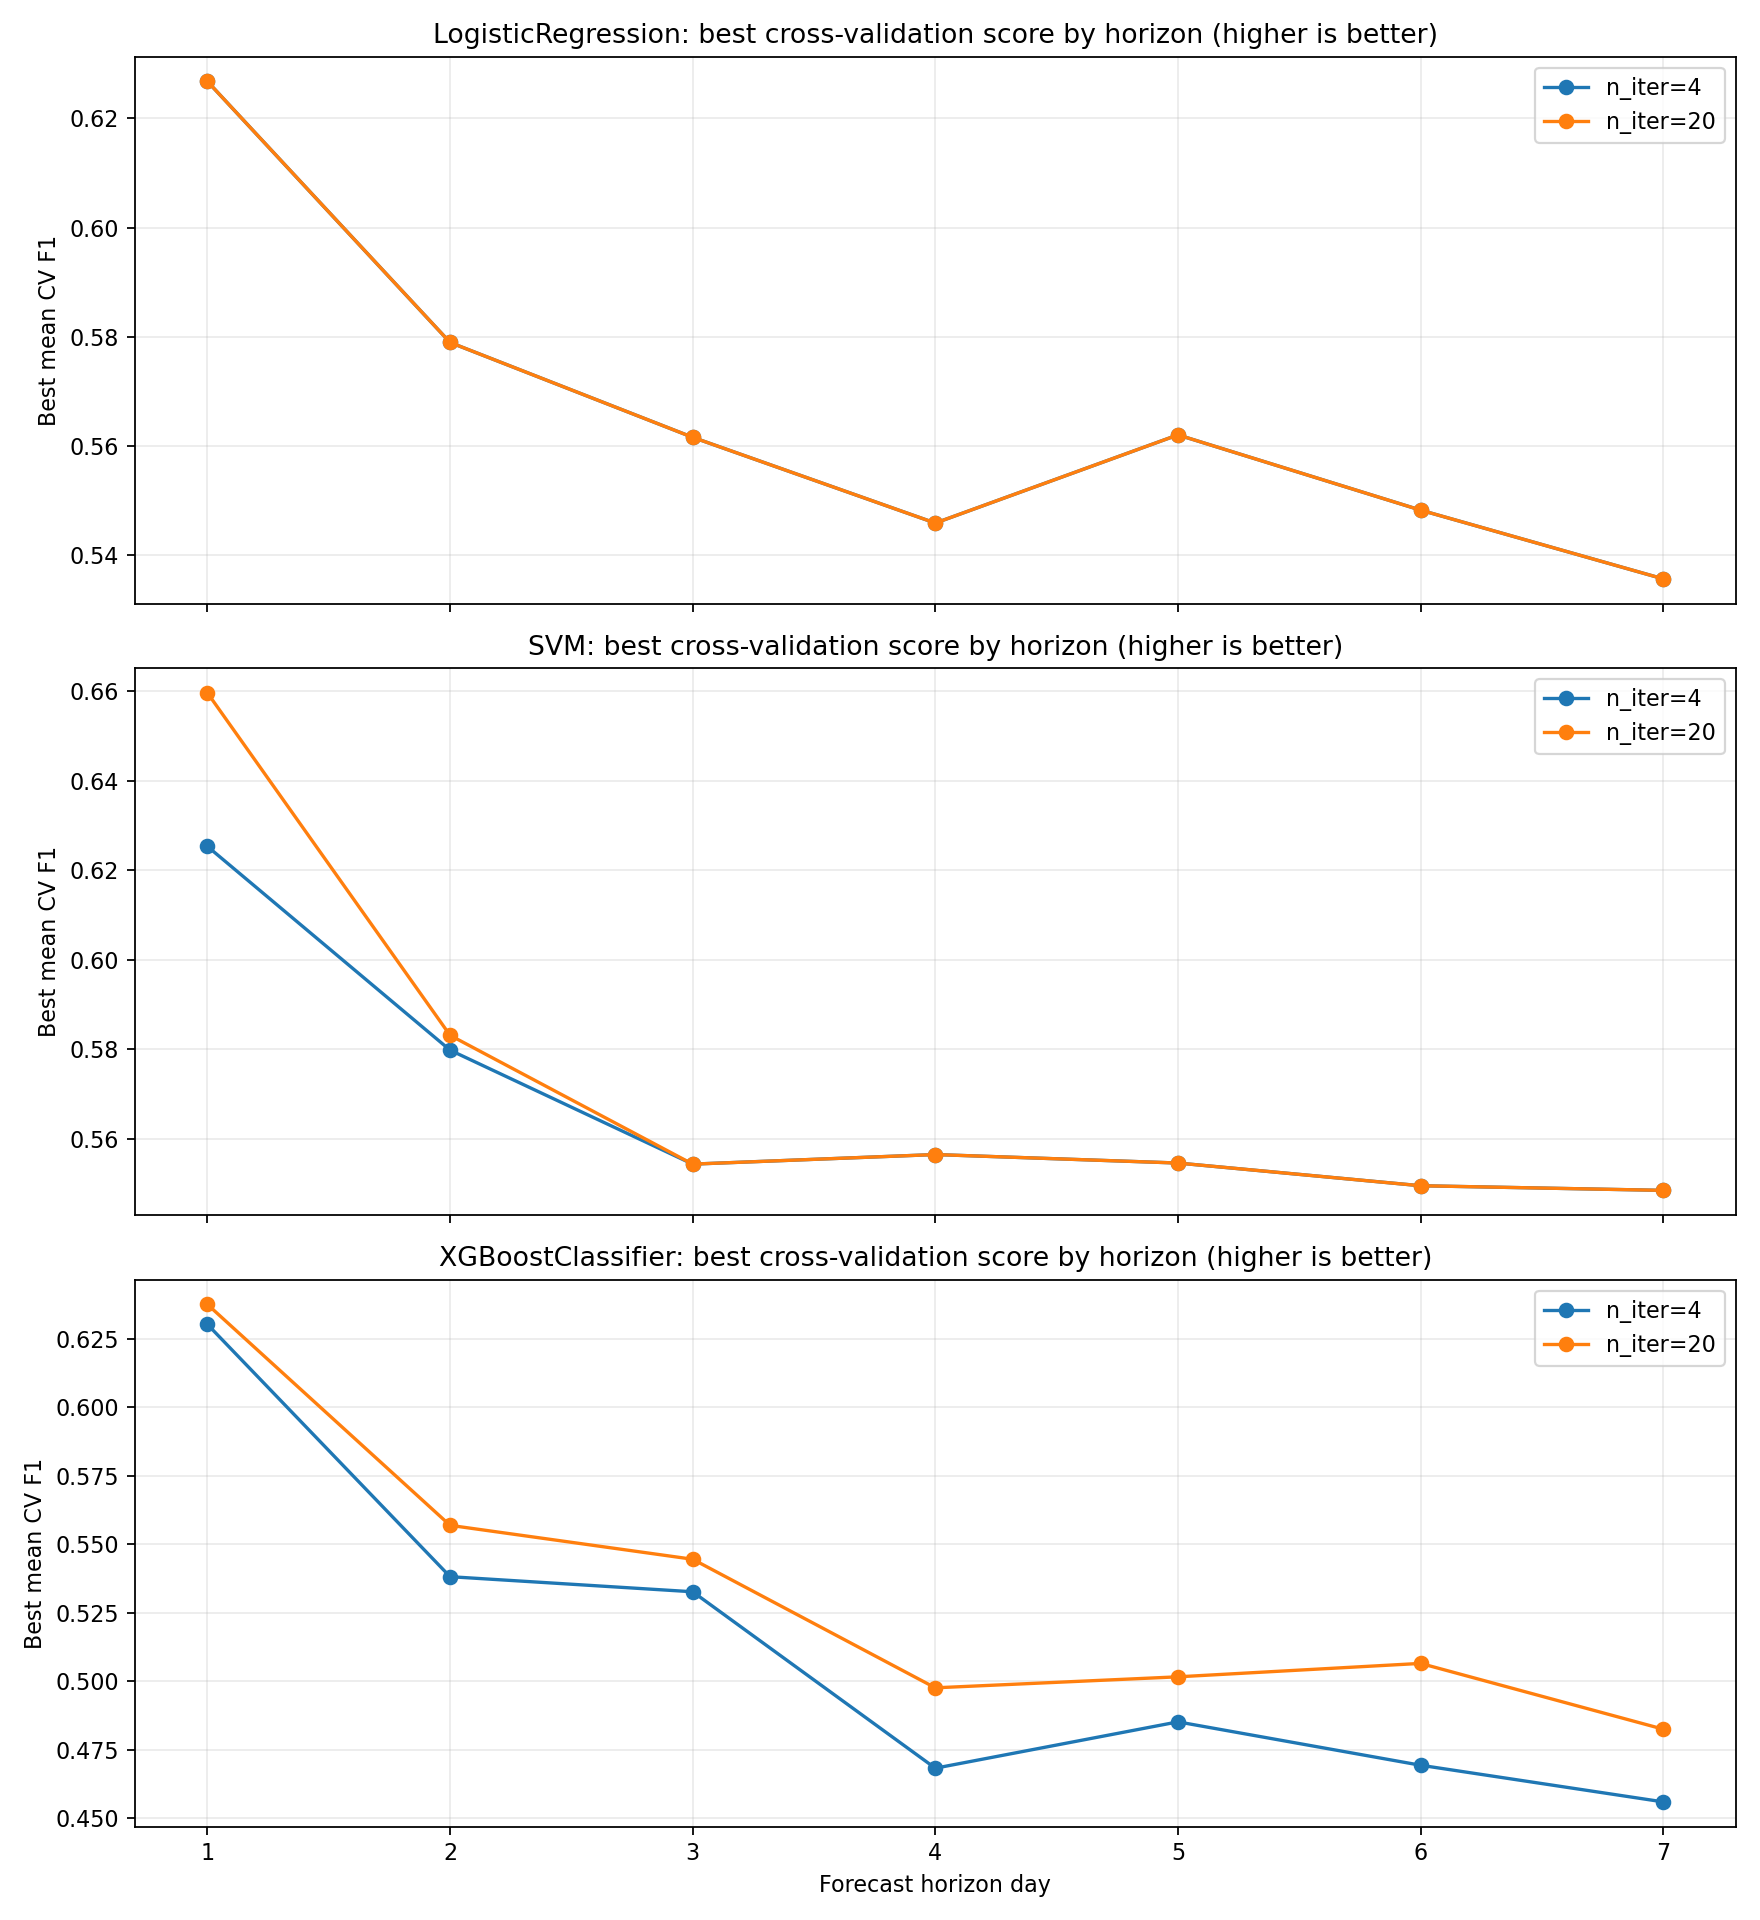
<figcaption aria-hidden="true">So sánh tuning CV F1 theo từng model
mưa</figcaption>
</figure>

Với các model có search space nhỏ như Logistic Regression và SVM, tăng
`n_iter` có thể nhanh chóng chạm giới hạn số cấu hình khả dụng. Với
XGBoost, search space lớn hơn nhiều; do đó `n_iter=20` có cơ hội tìm
được cấu hình cây tốt hơn so với `n_iter=4`.


# 10. Kết quả suy luận 7 ngày tương lai

Kết quả dự báo được sinh từ bản ghi 12:00 mới nhất trong dữ liệu, tức
2025-12-30 12:00. Bảy ngày dự báo cụ thể là từ 2025-12-31 đến
2026-01-06.

| Ngày dự báo | Mô hình nhiệt độ | Nhiệt độ dự báo | Mô hình mưa | Xác suất mưa | Threshold | Nhãn mưa | Mức thời tiết |
|---------|---------|----------:|---------|----------:|----------:|---------|---------|
| 2025-12-31 | XGBoostRegressor | 22,951 | XGBoostClassifier | 0,314 | 0,35 | no_rain | normal |
| 2026-01-01 | XGBoostRegressor | 20,880 | LogisticRegression | 0,229 | 0,40 | no_rain | cool |
| 2026-01-02 | XGBoostRegressor | 20,150 | LogisticRegression | 0,241 | 0,45 | no_rain | cool |
| 2026-01-03 | XGBoostRegressor | 18,374 | LogisticRegression | 0,268 | 0,40 | no_rain | cool |
| 2026-01-04 | XGBoostRegressor | 16,657 | LogisticRegression | 0,261 | 0,50 | no_rain | cool |
| 2026-01-05 | XGBoostRegressor | 17,840 | XGBoostClassifier | 0,127 | 0,45 | no_rain | cool |
| 2026-01-06 | XGBoostRegressor | 18,283 | SVM | 0,285 | 0,40 | no_rain | cool |

<figure>
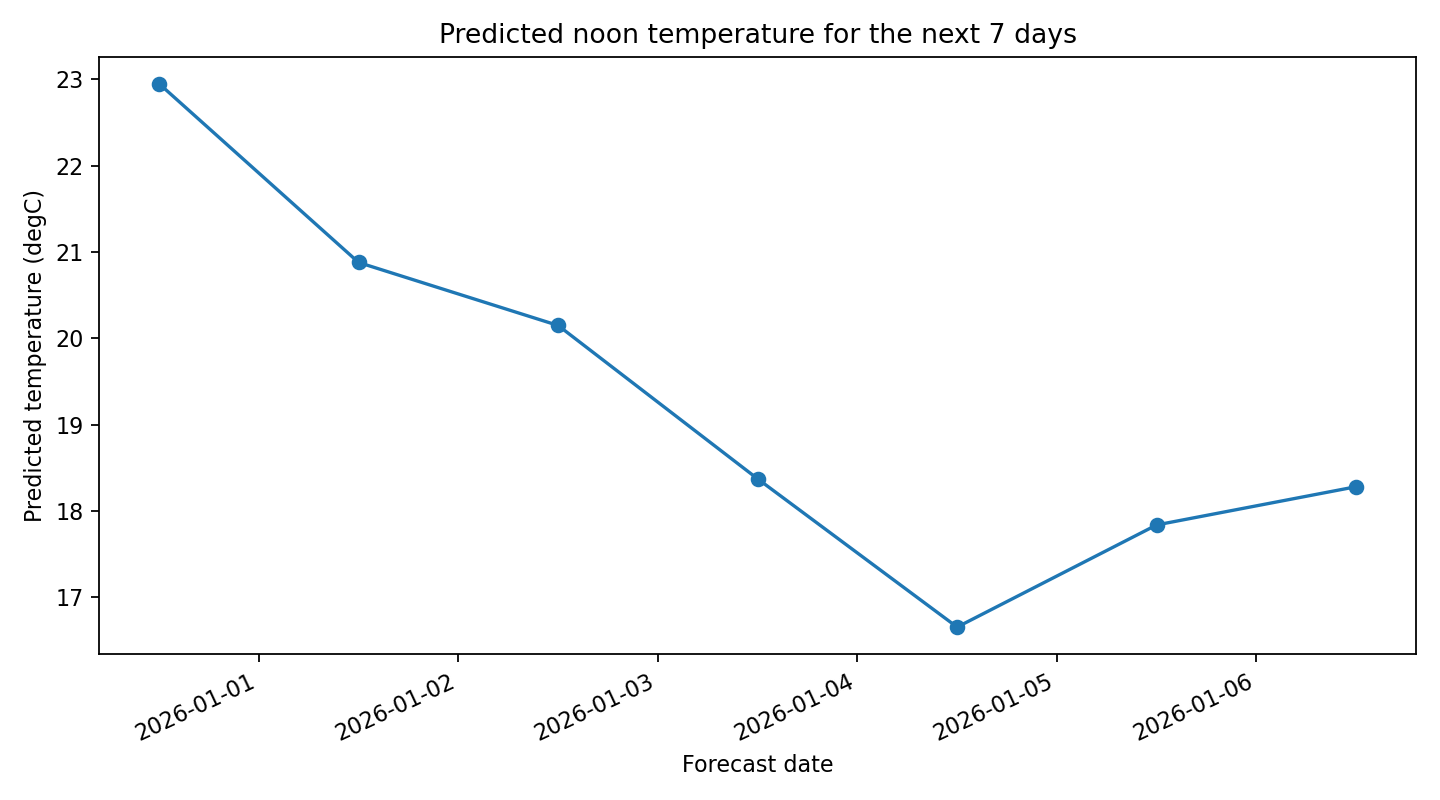
<figcaption aria-hidden="true">Dự báo nhiệt độ 7 ngày</figcaption>
</figure>

<figure>
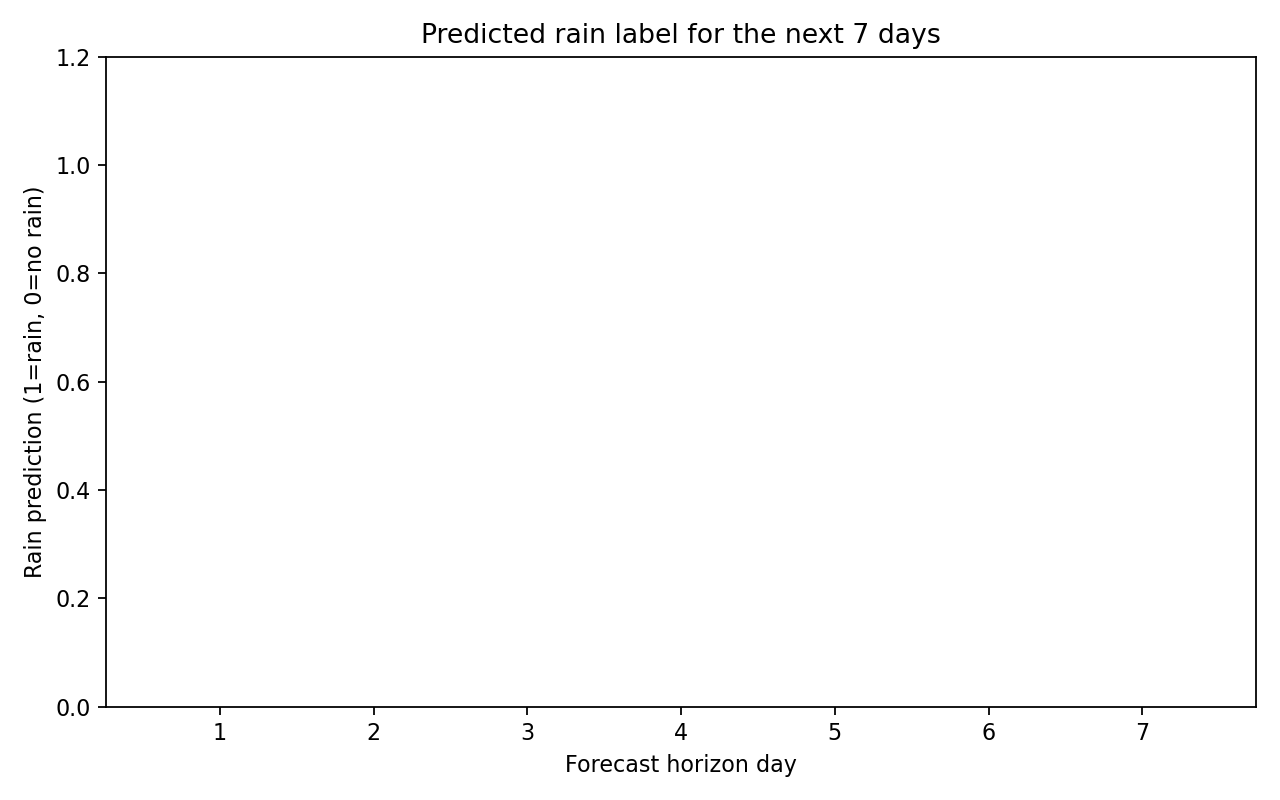
<figcaption aria-hidden="true">Dự báo mưa 7 ngày</figcaption>
</figure>

Mô hình dự báo toàn bộ 7 ngày là không mưa tại thời điểm 12:00 vì xác
suất mưa đều thấp hơn threshold đã chọn. Nhiệt độ dự báo chuyển từ mức
normal ở ngày đầu sang cool ở các ngày tiếp theo.


# 11. Đánh giá actual-predicted trên test set

<figure>
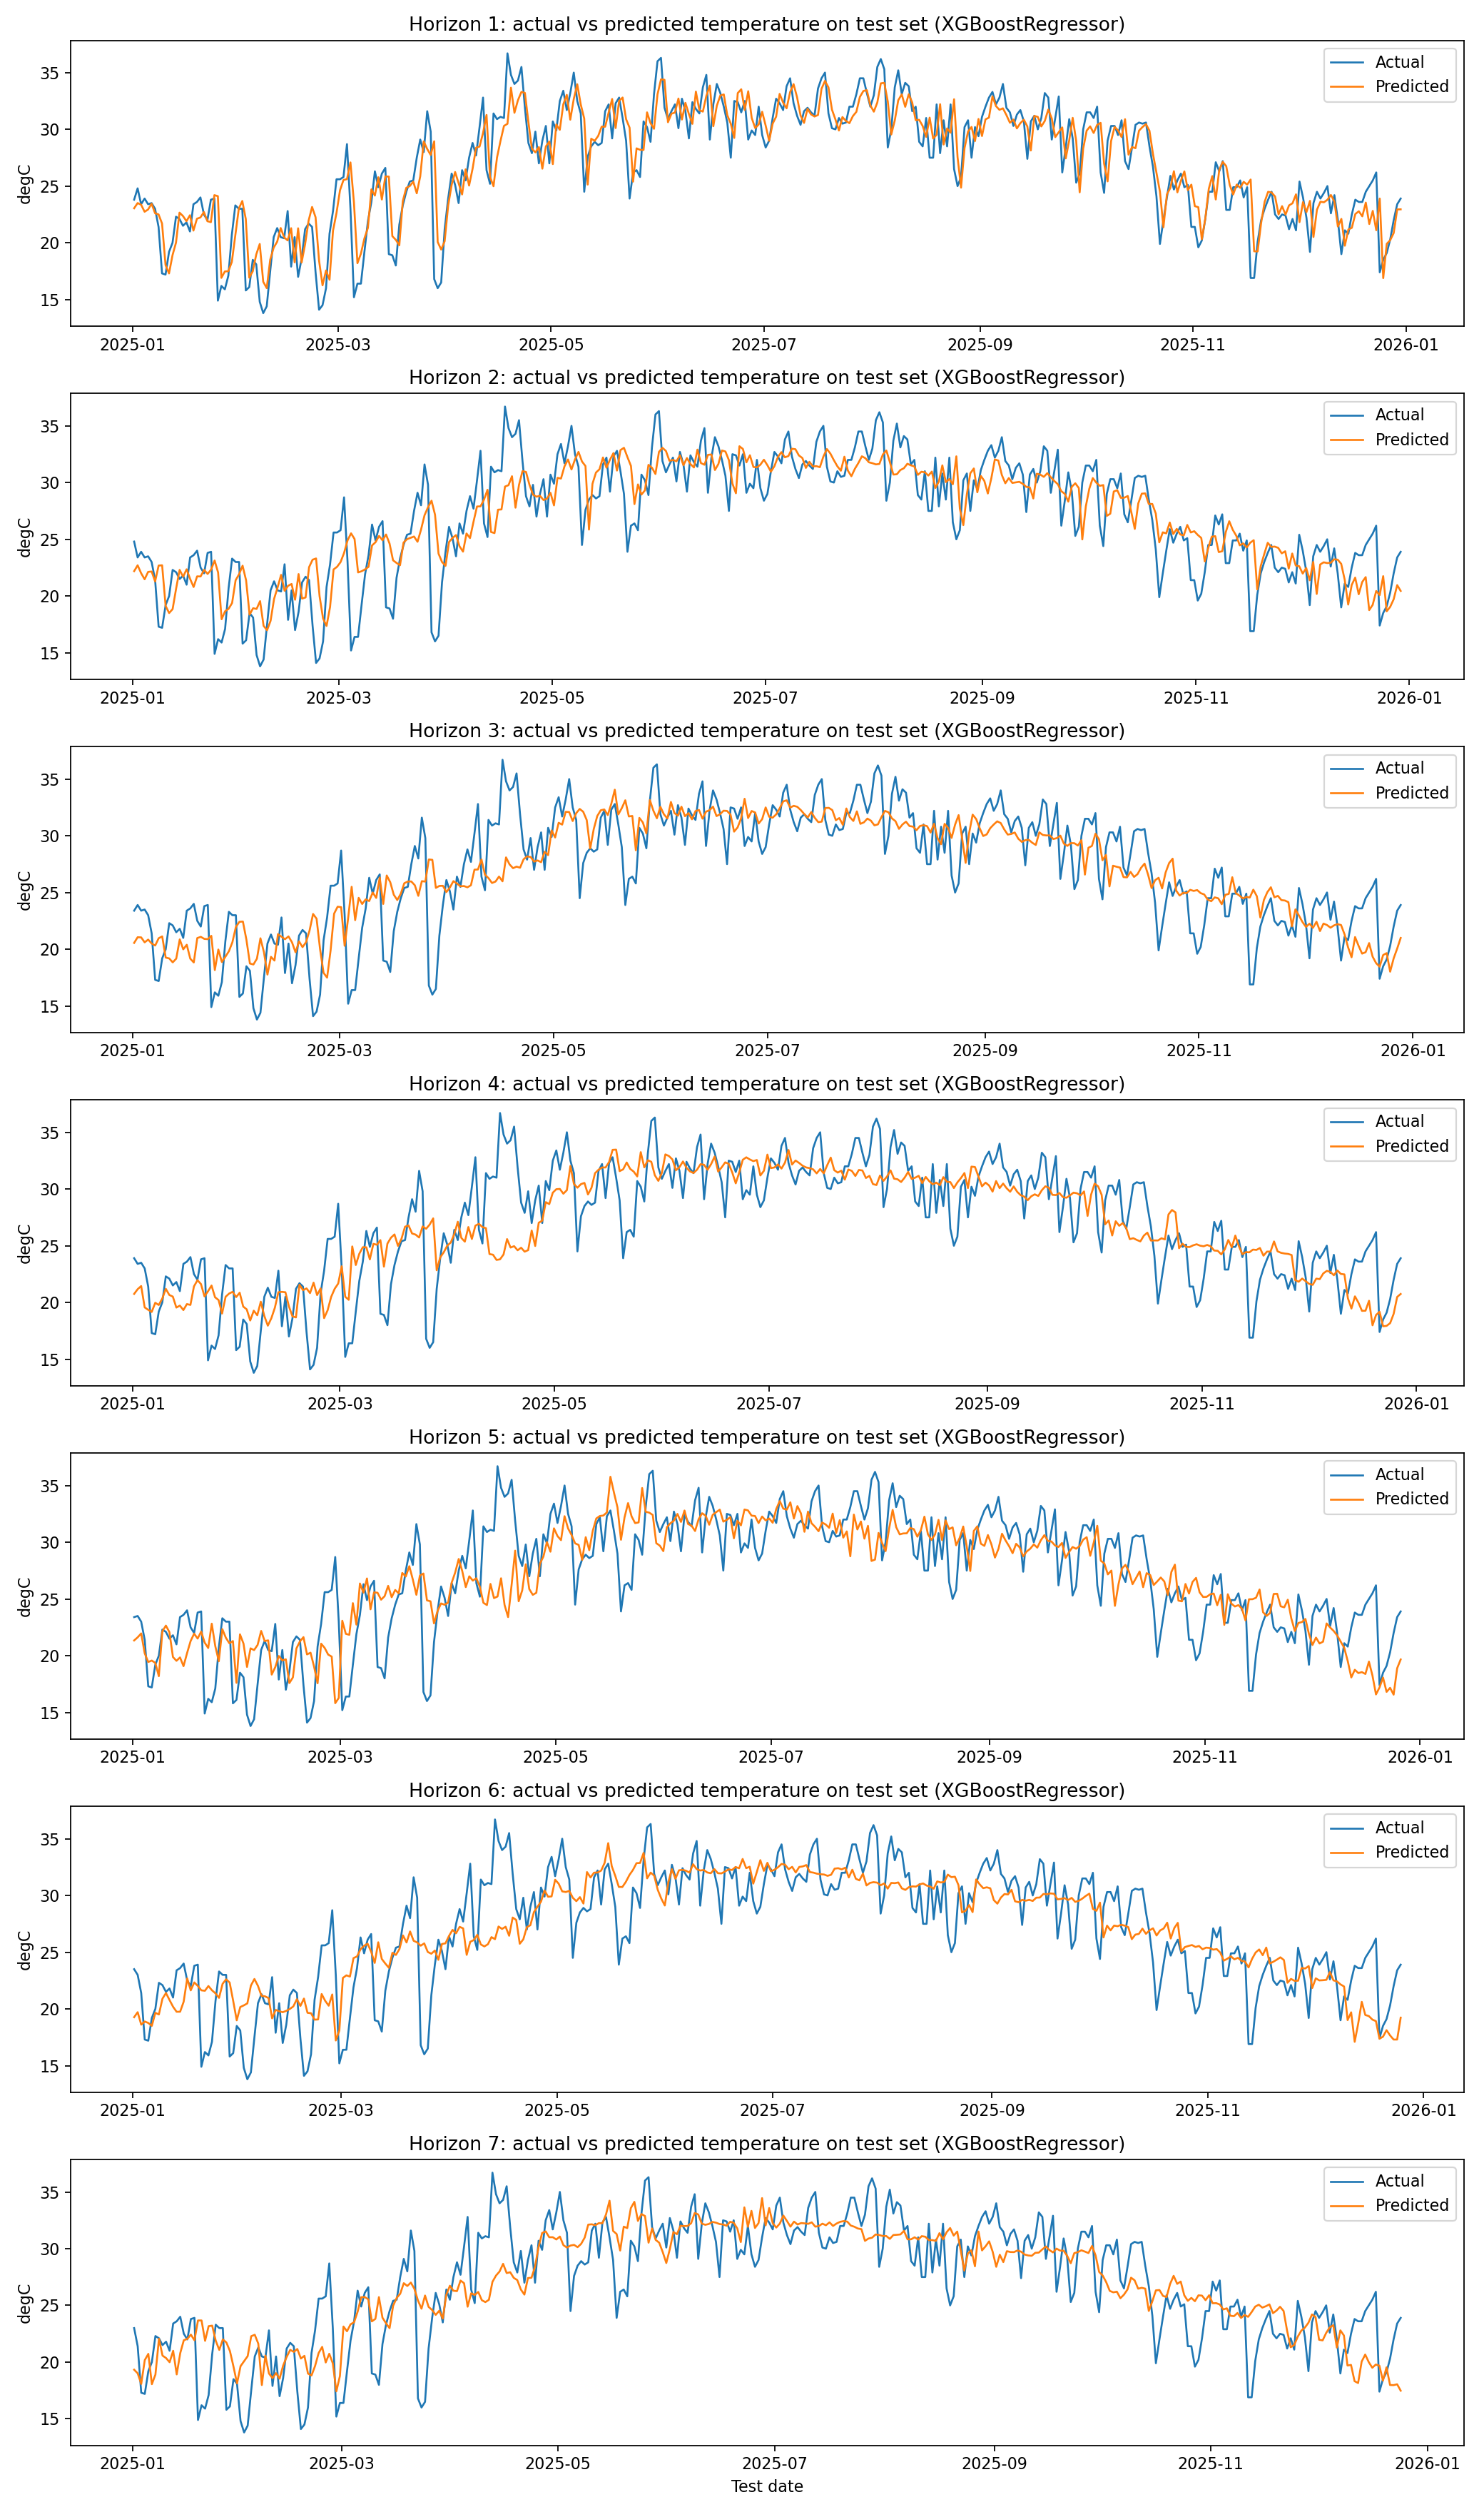
<figcaption aria-hidden="true">Actual vs predicted temperature on full
test set</figcaption>
</figure>

Biểu đồ nhiệt độ actual-predicted trên toàn bộ test set năm 2025 cho
thấy mô hình bám được xu hướng mùa vụ và dao động chính của nhiệt độ.
Sai lệch tăng ở các horizon xa, phù hợp với nguyên lý dự báo: càng xa
hiện tại, độ bất định càng lớn.

<figure>
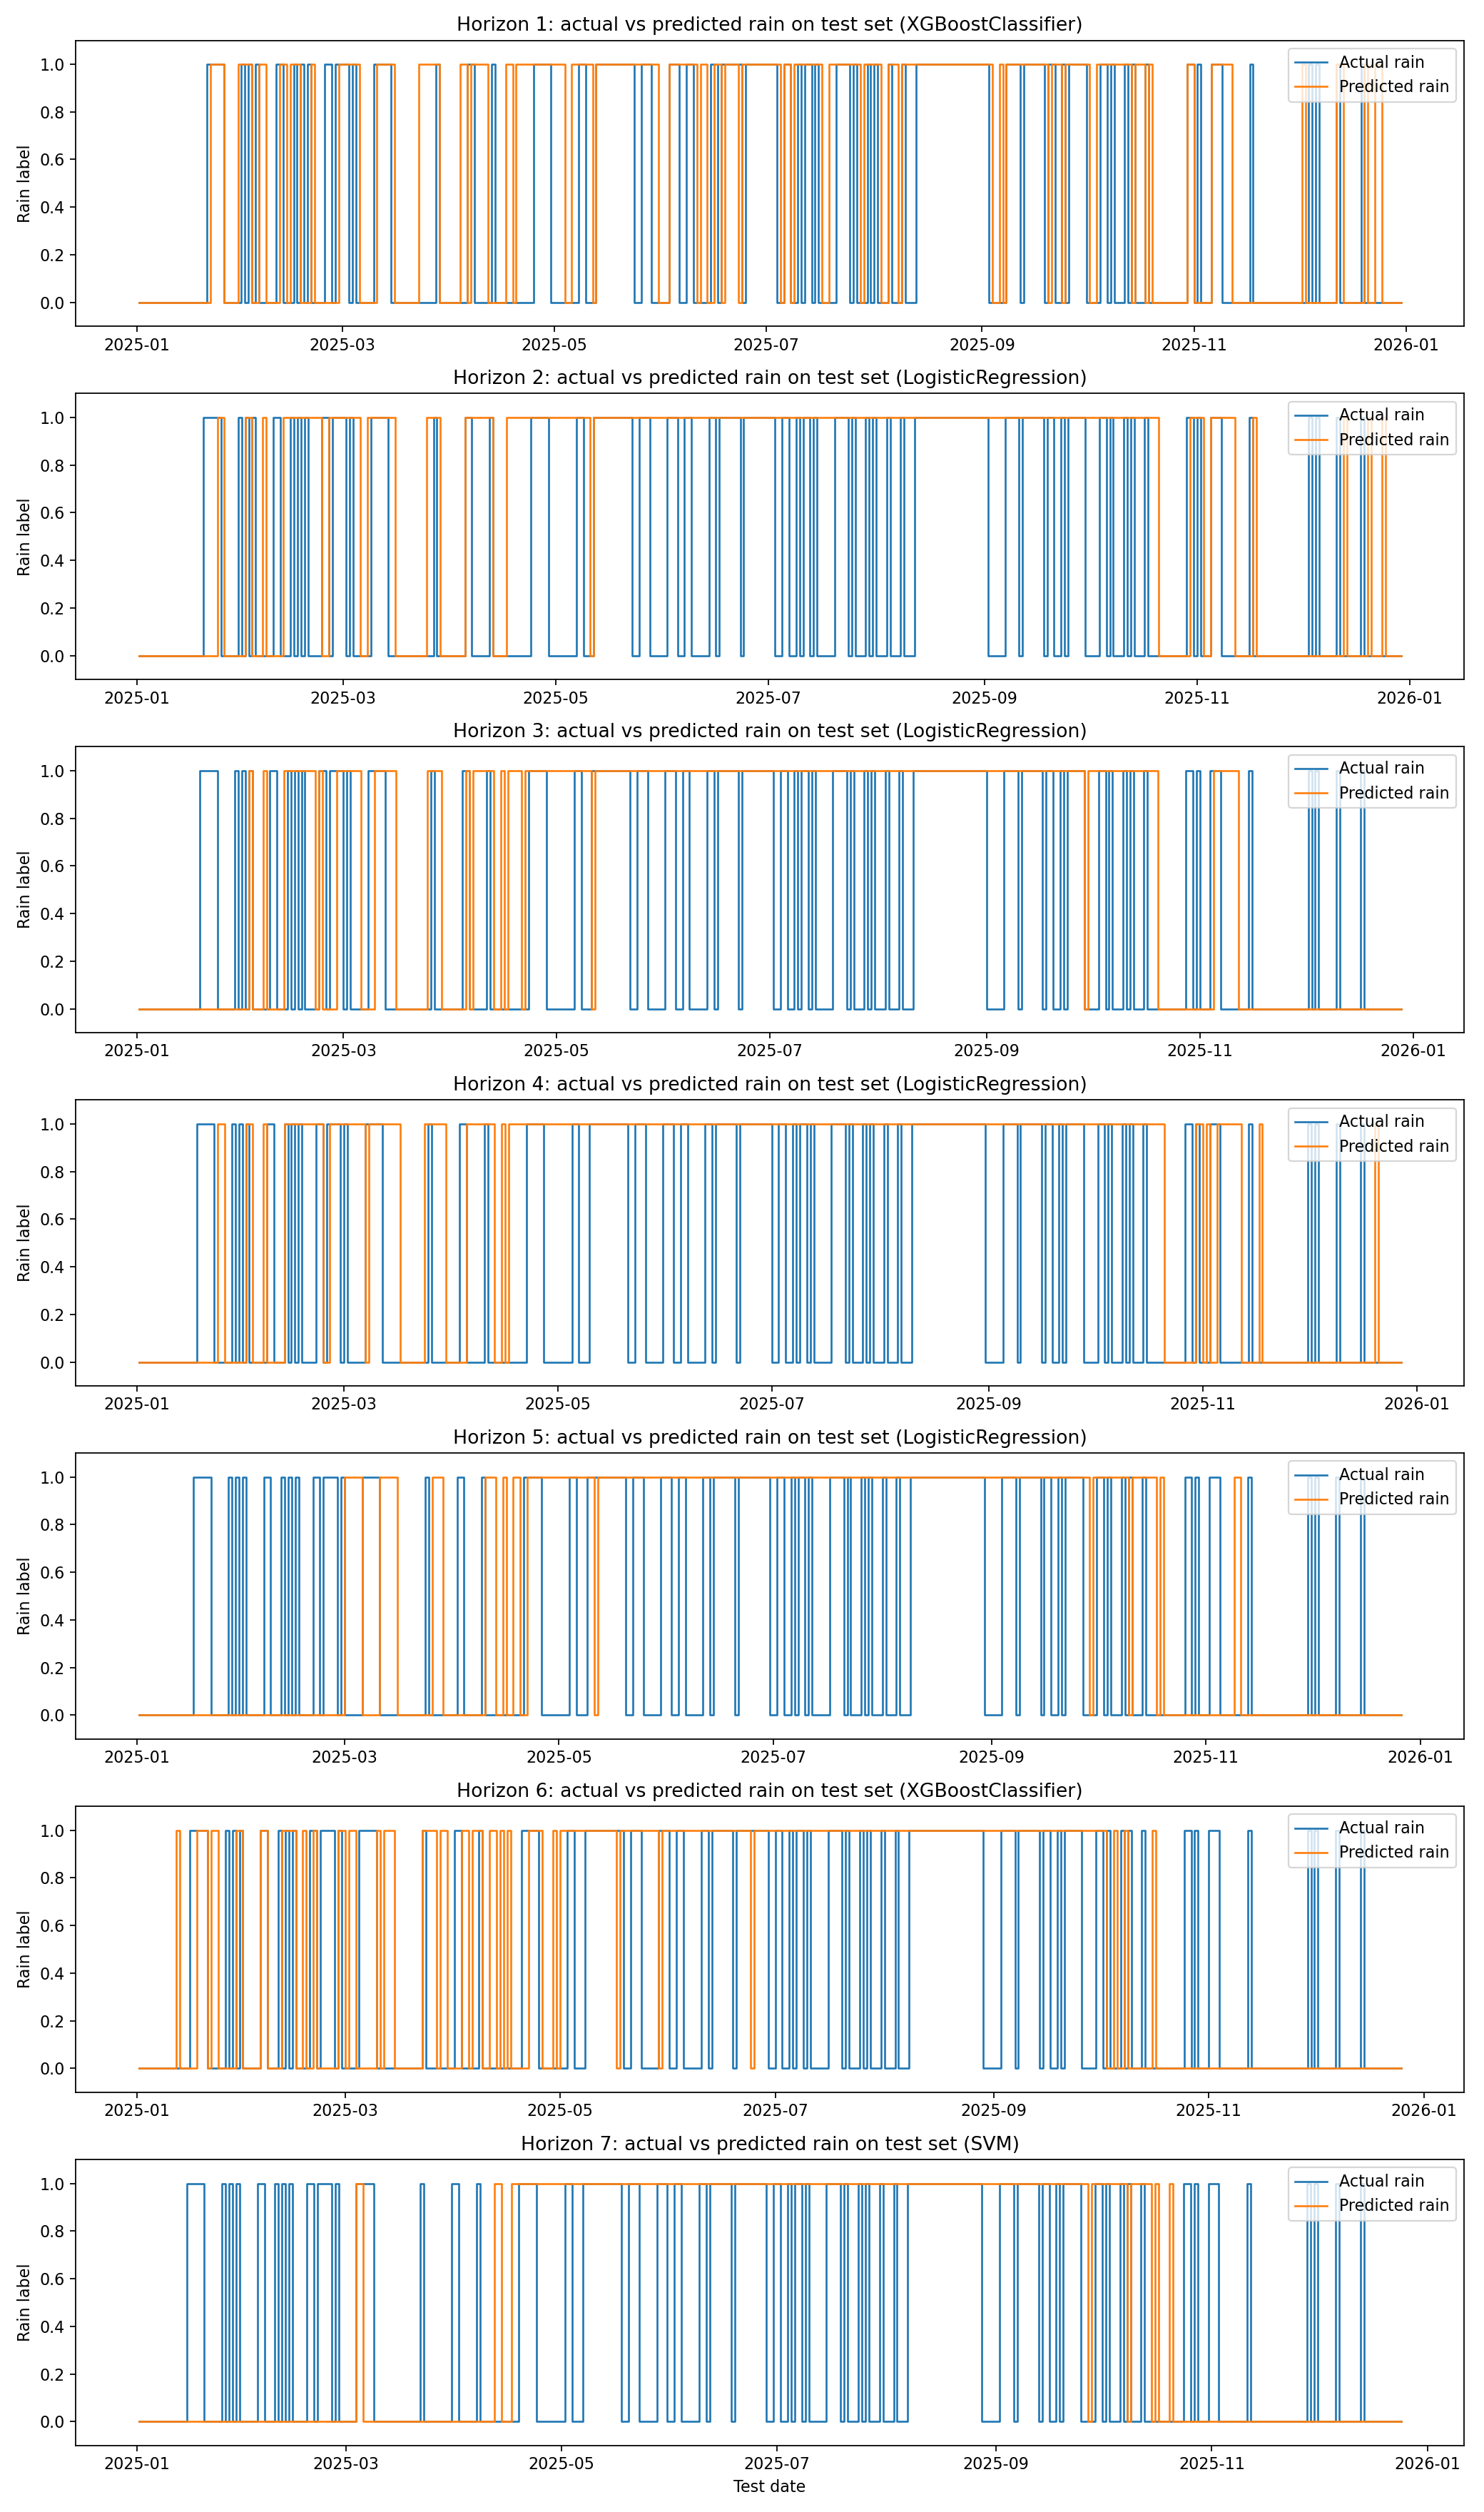
<figcaption aria-hidden="true">Actual vs predicted rain on full test
set</figcaption>
</figure>

Biểu đồ mưa actual-predicted cho thấy mô hình phân loại mưa còn sai đáng
kể. Điều này phù hợp với F1 ở mức trung bình, vì mưa là sự kiện thưa và
khó tách. Để cải thiện đáng kể bài toán mưa, cần thêm dữ liệu dự báo khí
tượng tương lai, dữ liệu nhiều thời điểm trong ngày hoặc dữ liệu không
gian từ khu vực lân cận.


# 12. Feature importance và diễn giải mô hình

Feature importance cần được hiểu theo từng loại mô hình. Với Linear
Regression và Logistic Regression, hệ số sau chuẩn hóa cho biết chiều và
độ mạnh tương đối của ảnh hưởng tuyến tính. Với XGBoost, importance phản
ánh mức độ đặc trưng được dùng trong các cây để giảm lỗi. Với KNN và
SVM, permutation importance đo mức suy giảm hiệu năng khi tráo một đặc
trưng.

<figure>
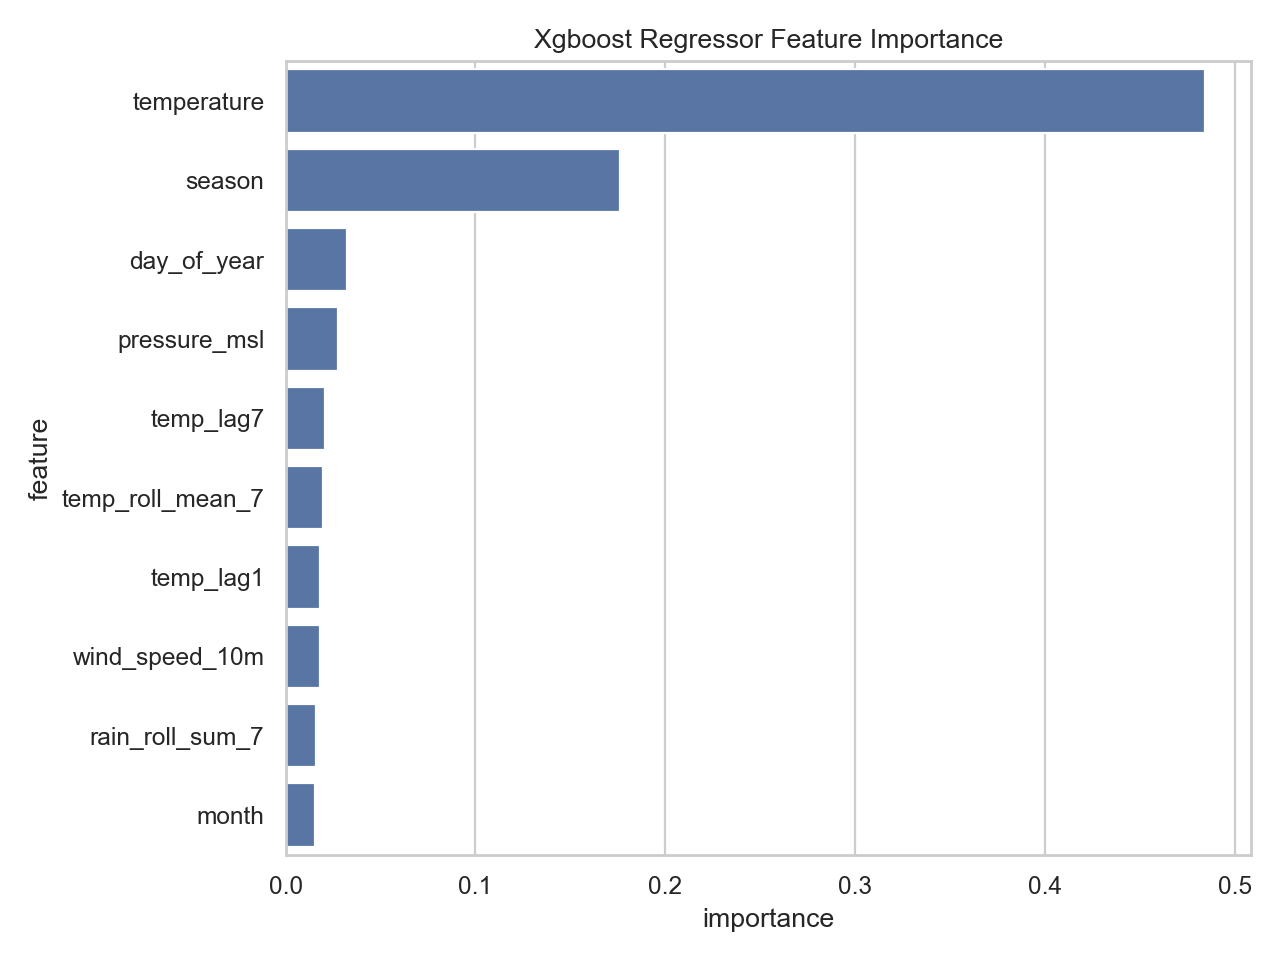
<figcaption aria-hidden="true">XGBoost Regressor feature
importance</figcaption>
</figure>

<figure>
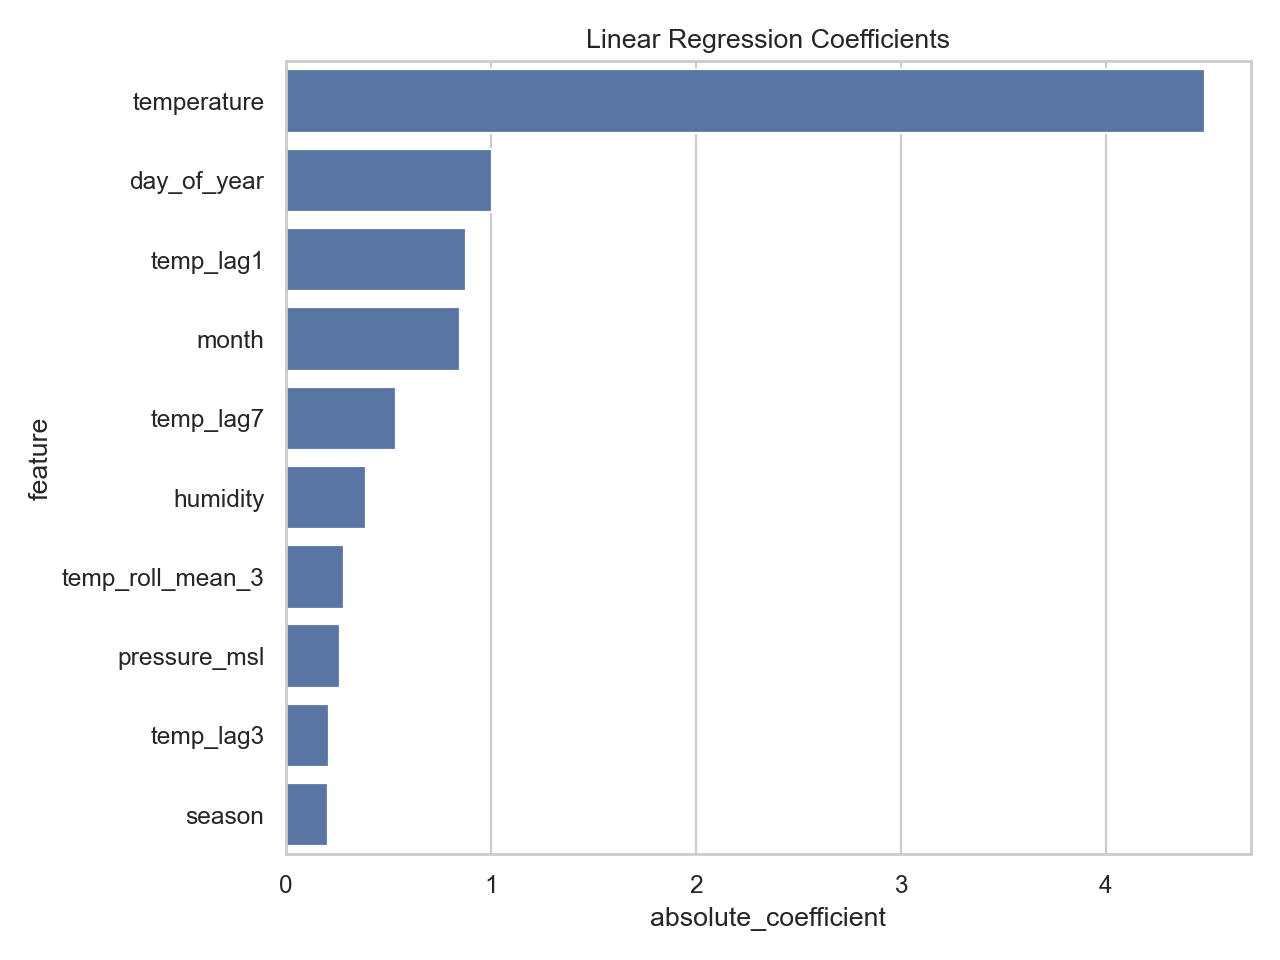
<figcaption aria-hidden="true">Linear Regression
coefficients</figcaption>
</figure>

<figure>
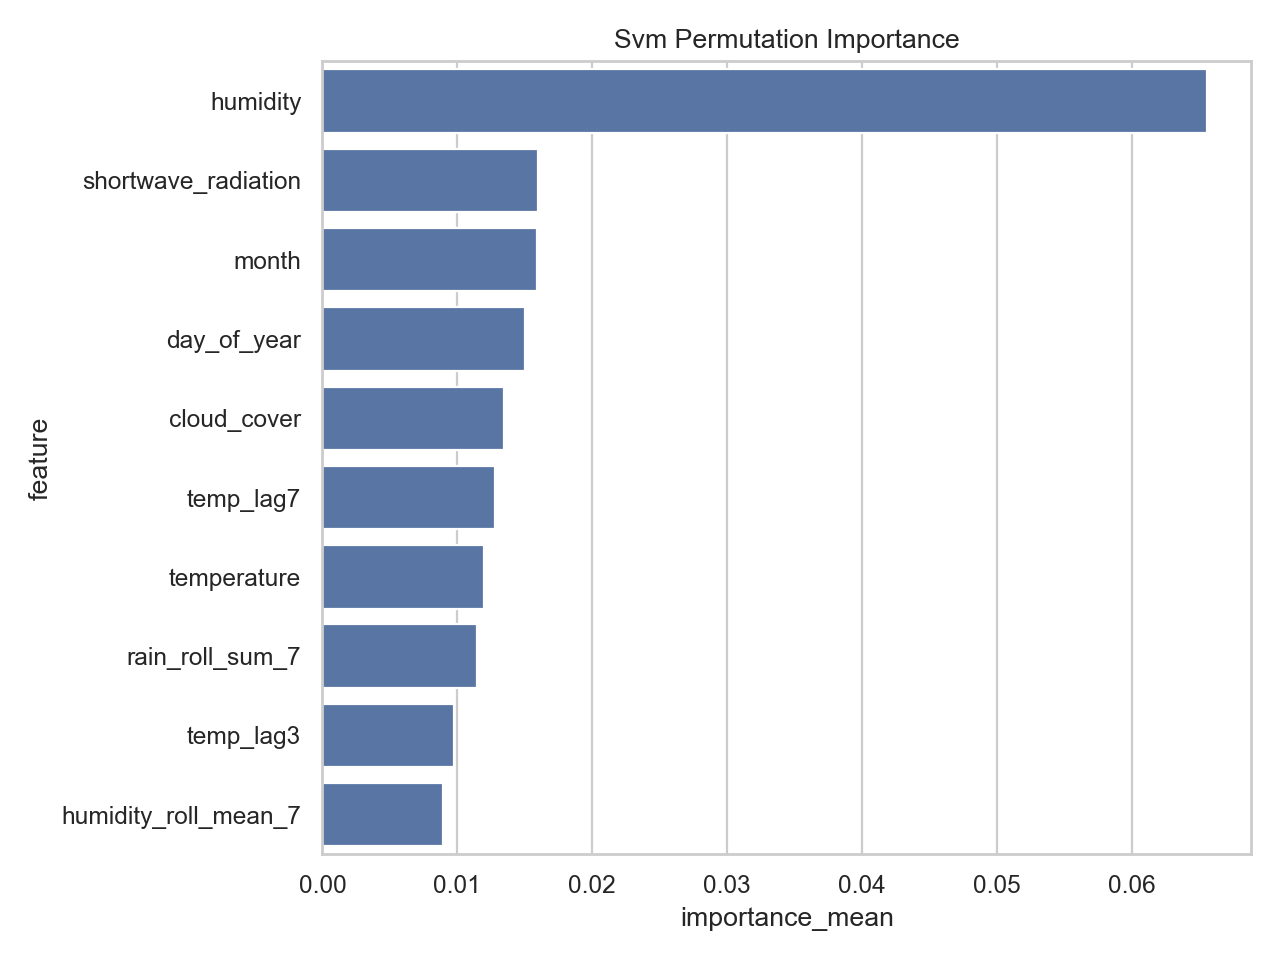
<figcaption aria-hidden="true">SVM permutation importance</figcaption>
</figure>

Feature importance không phản ánh model nào là tốt nhất. Chất lượng mô
hình phải được đánh giá bằng các metric trên validation/test như RMSE,
MAE, R2, F1 và ROC AUC. Feature importance chỉ trả lời câu hỏi mô hình
đang dựa nhiều vào đặc trưng nào trong quá trình ra quyết định.


# 13. Diễn giải các chỉ số đánh giá

MAE là sai số tuyệt đối trung bình. Với nhiệt độ, MAE 1,674 nghĩa là
trung bình dự báo lệch khoảng 1,674°C so với thực tế. MAE dễ hiểu nhưng
không phạt mạnh các lỗi lớn.

RMSE là căn bậc hai của sai số bình phương trung bình. RMSE phạt các lỗi
lớn mạnh hơn MAE; vì vậy RMSE thấp hơn nghĩa là mô hình ít mắc các lỗi
dự báo lệch xa.

R2 đo tỷ lệ phương sai của biến mục tiêu được mô hình giải thích. R2 gần
1 là tốt; R2 gần 0 nghĩa là mô hình không tốt hơn nhiều so với việc dự
báo bằng giá trị trung bình. Trong dự báo 7 ngày, R2 giảm khi horizon
dài hơn là hiện tượng hợp lý.

Within ±1°C, ±2°C và ±3°C cho biết tỷ lệ dự báo nằm trong một khoảng sai
số chấp nhận được. Chỉ số này hữu ích hơn cách nói đúng/sai tuyệt đối
trong hồi quy vì nhiệt độ là biến liên tục.

Accuracy là tỷ lệ dự báo đúng tổng thể trong phân loại mưa. Precision
cho biết trong các lần mô hình dự báo mưa, bao nhiêu lần thực sự có mưa.
Recall cho biết trong các ngày thực sự có mưa, mô hình phát hiện được
bao nhiêu. F1 là trung bình điều hòa giữa precision và recall, phù hợp
khi dữ liệu mất cân bằng. ROC AUC đo khả năng xếp hạng xác suất giữa lớp
mưa và không mưa.


# 14. Thảo luận học thuật

Kết quả thực nghiệm cho thấy bài toán nhiệt độ dễ dự báo hơn bài toán
mưa. Nguyên nhân chính là nhiệt độ có tính liên tục theo thời gian và
chịu ảnh hưởng mạnh của mùa vụ. Ngược lại, mưa là hiện tượng cục bộ, rời
rạc và chịu ảnh hưởng của nhiều yếu tố khí quyển mà dữ liệu một điểm lúc
12:00 không thể mô tả đầy đủ.

Trong bài toán ngày kế tiếp, Linear Regression đạt kết quả tốt nhất cho
nhiệt độ. Điều này không có nghĩa Linear Regression luôn mạnh hơn
XGBoost, mà phản ánh rằng với horizon ngắn và tập dữ liệu hiện có, quan
hệ tuyến tính đã đủ hiệu quả. Trong bài toán 7 ngày, XGBoostRegressor
chiếm ưu thế vì dự báo xa hơn yêu cầu mô hình hóa quan hệ phi tuyến và
tương tác đặc trưng phức tạp hơn.

Việc tăng `n_iter` từ 4 lên 20 làm rõ vai trò của hyperparameter tuning.
Khi chỉ thử 4 cấu hình, kết quả có thể phụ thuộc mạnh vào các mẫu ngẫu
nhiên ban đầu. Khi thử 20 cấu hình, xác suất tìm được cấu hình phù hợp
hơn tăng lên, đặc biệt với XGBoost. Tuy nhiên, tăng `n_iter` không bảo
đảm mọi horizon đều tốt hơn vì validation/test có thể khác phân phối, và
mô hình được chọn theo validation không được tối ưu trực tiếp trên test.

Đối với mưa, tuning threshold là cần thiết. Nếu dùng threshold mặc định
0,5, mô hình có thể quá bảo thủ và dự báo nhiều ngày không mưa.
Threshold tối ưu theo validation set giúp cân bằng precision và recall
theo F1. Tuy nhiên, threshold tuning chỉ điều chỉnh quyết định đầu ra,
không thay thế được việc cần thêm đặc trưng khí tượng mạnh hơn.


# 15. Hạn chế

Thứ nhất, dữ liệu chỉ sử dụng một điểm không gian là Hà Nội và chỉ lấy
thời điểm 12:00. Điều này làm bài toán rõ ràng nhưng mất thông tin về
diễn biến theo giờ và cấu trúc không gian của thời tiết.

Thứ hai, pipeline dự báo 7 ngày dùng direct multi-horizon từ bản ghi
hiện tại, không tự sinh toàn bộ chuỗi biến khí hậu tương lai như độ ẩm,
áp suất, gió, mây hay bức xạ. Vì vậy, mô hình đang học quan hệ từ trạng
thái hiện tại/quá khứ sang target tương lai, chứ không mô phỏng khí
quyển đầy đủ.

Thứ ba, test set chỉ là năm 2025. Mặc dù đánh giá này đúng quy trình,
kết quả vẫn có thể chịu ảnh hưởng bởi đặc điểm riêng của năm đó. Nhiều
năm test hơn sẽ giúp kết luận ổn định hơn.

Thứ tư, bài toán mưa được chuyển thành nhị phân `precipitation > 0`.
Trong thực tế, mưa rất nhỏ và mưa đáng kể có ý nghĩa sử dụng khác nhau.
Một hướng cải thiện là dự báo nhiều mức mưa hoặc dự báo lượng mưa liên
tục rồi suy ra nhãn.


# 16. Kết luận và hướng phát triển

Dự án đã xây dựng thành công pipeline học máy cho dự báo thời tiết Hà
Nội lúc 12:00, bao gồm dự báo ngày kế tiếp và dự báo 7 ngày. Hệ thống
thực hiện đầy đủ các bước của một quy trình học máy học thuật: tiền xử
lý dữ liệu, phân tích thống kê, trực quan hóa, tạo đặc trưng không rò rỉ
dữ liệu, chia train/validation/test theo thời gian, tuning tham số bằng
`TimeSeriesSplit`, lựa chọn mô hình bằng validation set, đánh giá cuối
trên test set và sinh báo cáo kết quả.

Với bài toán ngày kế tiếp, Linear Regression là mô hình tốt nhất cho
nhiệt độ với RMSE test 2,319°C và R2 0,808. Với bài toán mưa ngày kế
tiếp, SVM được chọn theo validation F1 và đạt F1 test 0,673. Với bài
toán dự báo 7 ngày, phiên bản `n_iter=20` là phiên bản thuyết phục hơn
vì cải thiện RMSE trung bình của nhiệt độ từ 3,290 xuống 3,159 và F1
trung bình của mưa từ 0,625 lên 0,632.

Trong tương lai, hệ thống có thể được cải thiện bằng cách bổ sung dữ
liệu nhiều thời điểm trong ngày, dữ liệu không gian từ các khu vực lân
cận, biến khí tượng dự báo từ mô hình số trị, hoặc dữ liệu ảnh
mây/radar. Ngoài ra, có thể thử các mô hình chuỗi thời gian như LSTM,
Temporal Convolutional Network hoặc Transformer, nhưng cần đánh giá cẩn
thận để tránh overfitting trên tập dữ liệu còn tương đối nhỏ.
